# Plots analyse cluster/niche labeled samples

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from time import time
import anndata as ad
import scanpy as sc
import copy
from umap import UMAP
import leidenalg as la
from tysserand import tysserand as ty
from mosna import mosna as mosna
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
#from phenograph.cluster import cluster
import glob
from pathlib import Path
from tqdm import tqdm
import json
import numpy as np
import os, random
from scipy.stats import zscore

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

## Initialisation variables et des paramètres pour plots

In [777]:

def get_reducer_dir_name(cluster_params, reducer_dir_name):
    #fonction pour récupérer le nom du dossier cluster
    #cluster_params = dico
    #reducer dir name = str
    if cluster_params["clusterer_type"] == 'leiden':
        n_neighbors = str(cluster_params["n_neighbors"])
        k_cluster = str(cluster_params["k_cluster"])
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}_n_neighbors-{k_cluster}'
    elif cluster_params["clusterer_type"] == 'spectral' or cluster_params["clusterer_type"] == 'ecg':
        k_cluster = str(cluster_params["k_cluster"])
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}_n_neighbors-{k_cluster}'
    else : 
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}'
    return clusterer_dir_name

In [778]:

cluster_params = {
    'reducer_type' : 'umap',
   'clusterer_type':'leiden',
   'n_clusters':7,
   'force_recompute' : False,
   'resolution' : 0.05,
   'n_neighbors' : 20,
   'k_cluster' : 15
   #résolution que pour leiden
   
}

reducer_dir_name = "reducer-umap_dim-2_nneigh-20_metric-manhattan_min_dist-0.0"
clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)

chemin = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT_merged/nodes_cluster_leiden_labeled.parquet'
nodes_cluster_labeled_file_path = Path(chemin)

info_metadata_path = Path('./images_metadatainfo.csv')

#dossiers vers nodes_cluster_labeled
dossier = './OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/analyses_complementaires_niches_20_merged/nodes_cluster_labeled'

In [779]:


#nombre de niches au total
nb_niches = 38

#ordre dans lequel on veut que les bars du barlot apparaissent dans le plot number cell per niche per location
order = ["Adjacent_normal", "Dysplasia", "Tumour_stroma", "Tumour"]

normalize = True # normalisé  on prend proportion de celulles par sample pour chaque niche
#if normalize:
    #normalisation par ligne/patient dans le code dendrogramme : 
    # heatmap_data = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)nombre de cellule dans un sample qui sont dans une niche en prenant proportion

without_normal = True
'''
without normal == True ça lance sans les samples ROI adjacent normal, ça crée un dossier dans plot avec ces plots dedans 
mais sans les barplots qui eux sont générés avec tous les samples donc vaut mieux lancer une fois False puis True
'''

drop_homo_assort = False # permet de ne pas prendre en compte dans les PCA les assort self interaction

save = True
#path vers me dossier où save les plots
path = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/analyses_complementaires_niches_20_merged/'
plot_dir = Path(f'{path}/plots')
plot_dir.mkdir(parents=True,exist_ok=True)

if without_normal == True :
    save_bar_plot = False
else :
    save_bar_plot = True
    bar_plot_dir = plot_dir



if without_normal == True :
    plot_dir = Path(f'{path}/plots/plots_without_adjacent_normal')
    plot_dir.mkdir(exist_ok=True)

location_to_color = None

# stats_data_dir = dossier avec stats d'assortativités générées 
stats_data_dir = Path("./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/assortativity/500_shuffles/group_stats_data_assortativity.parquet")



#palette prédéfinie manuellement pour locations 
location_to_color = {
'Tumour_stroma': (1.0, 1.0, 0.7019607843137254) ,
'Tumour': (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
'Dysplasia':(0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
'Adjacent_normal':(0.7450980392156863, 0.7294117647058823, 0.8549019607843137)}

## Récupération données

In [780]:
#je recupère le data frame avec tous les nodes et leur cluster

nodes_cluster_labeled = pd.read_parquet(nodes_cluster_labeled_file_path)



Récupération metainfos et liaison dans un df commmun avec les nodes

In [781]:
metadata = pd.read_csv(info_metadata_path)

In [782]:

#Je recupère patient et sample en pour chaque ligne de metainfo data et je mets ça dans colonne image sachant que de la forme 4 derniers chiffre = 2 premiers patient, deux derniere sample
metadata = metadata.copy()

metadata["patient"] = metadata["image"].str[6:8]
metadata["sample"] = metadata["image"].str[8:10]

metadata["id"] = "patient-" + metadata["patient"] + "_sample-" + metadata["sample"]

metadata = metadata.set_index('id')

In [783]:
metadata.head()

,image,width_px,height_px,num_channels,source_file,recovery_file,recovered,original image ID,Notes,Patient ID,For tumour only analysis,Pathology,Stage,Grade,Location in pancrea,Treatment before tissue collection,Diabetes,Pancreatitis,patient,sample
id,,,,,,,,,,,,,,,,,,,,
patient-01_sample-03,hPDAC_0103,1968,1089,38,S0868_M Chihara-Slide_01_Dysplasia_x32670_y119...,NaN,False,S0868_M Chihara-Slide_01_Dysplasia_x32670_y119...,dysplasia,A22TLYZ04-01,No,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,03
patient-01_sample-04,hPDAC_0104,1395,1578,38,S0868_M Chihara-Slide_01_adjacent normal_x1679...,NaN,False,S0868_M Chihara-Slide_01_adjacent normal_x1679...,adjacent normal,A22TLYZ04-01,No,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,04
patient-01_sample-02,hPDAC_0102,1395,1578,38,S0868_M Chihara-Slide_01_adjacent stroma_x2139...,NaN,False,S0868_M Chihara-Slide_01_adjacent stroma_x2139...,tumour stroma,A22TLYZ04-01,Yes,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,02
patient-01_sample-01,hPDAC_0101,1439,1534,38,S0868_M Chihara-Slide_01_tumour centre_x20222_...,NaN,False,S0868_M Chihara-Slide_01_tumour centre_x20222_...,tumour centre,A22TLYZ04-01,Yes,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,01
patient-02_sample-03,hPDAC_0203,1432,1472,38,S0869_M Chihara-Slide_02_adjacent stroma_1_x31...,NaN,False,S0869_M Chihara-Slide_02_adjacent stroma_1_x31...,tumour stroma,A22TLYZ04-02,Yes,Moderately differentiated ductal carcinoma,III,2,Head,"Yes, chemotherapy",No,No,02,03


In [784]:
#je récupère nodes_cluster_labeled_and_metadata = nodes_cluster_labeled (données nodes avec cluster) mais avec localisation précisée (region_grouped)

nodes_cluster_labeled_and_metadata = nodes_cluster_labeled.copy()
#je crée colone id  car source file colonne existe dans metainfo pour designer
#autre chose et ça va poser problème quand je vais réunir les deux dataframe. Et aussi, dans source file ça commence par
#nodes_ donc je supprime ça. 



import re

# -------------------------------
# Côté nodes
# -------------------------------

nodes_cluster_labeled_and_metadata["id"] = (
    nodes_cluster_labeled_and_metadata["source_file"]
    .str.replace("nodes_", "", regex=False)
    .str.replace(".parquet", "", regex=False)
    .str.strip()
)

nodes_cluster_labeled_and_metadata["id"] = (
    nodes_cluster_labeled_and_metadata["id"]
    .map(
        lambda x: re.sub(r'(\D)0+(\d+)', r'\1\2', x)
    )
)


# -------------------------------
# Côté metadata
# -------------------------------

metadata.index = (
    metadata.index
    .astype(str)
    .map(
        lambda x: re.sub(r'(\D)0+(\d+)', r'\1\2', x)
    )
)

metadata.index.name = "id"


# -------------------------------
# Merge
# -------------------------------

nodes_cluster_labeled_and_metadata = nodes_cluster_labeled_and_metadata.merge(
    metadata,
    left_on="id",
    right_index=True,
    how="left"
)


#nodes_cluster_labeled_and_metadata = nodes_cluster_labeled_and_metadata.set_index('id')
#nodes_cluster_labeled_and_metadata = nodes_cluster_labeled_and_metadata.join(metadata, how='inner')
#on standarise les noms de pathologie pour éviter les problèmes de mapping, parfois poorly est écrit avec un p minuscule et parfois avec un P majuscule.
nodes_cluster_labeled_and_metadata["Pathology"] = (
    nodes_cluster_labeled_and_metadata["Pathology"]
    .replace({
        "poorly differentiated ductal carcinoma": "Poorly differentiated ductal carcinoma"
    })
    .infer_objects(copy=False)
)
mapping = {
    'tumour': 'Tumour',
    'tumour centre': 'Tumour',
    'tumour_invasive area': 'Tumour',
    'tumour + islets': 'Tumour',
    'tumour incl. stroma and islets': 'Tumour',
    'tumor intraductal spread': 'Tumour',

    'tumour stroma': 'Tumour_stroma',
    'adjacent stroma': 'Tumour_stroma',

    'dysplasia': 'Dysplasia',
    'dysplasia + islets': 'Dysplasia',

    'adjacent normal': 'Adjacent_normal'
}


nodes_cluster_labeled_and_metadata['location'] = nodes_cluster_labeled_and_metadata['Notes'].map(mapping)
#nodes_cluster_labeled_and_metadata = nodes_cluster_labeled_and_metadata.reset_index()




In [785]:
nodes_cluster_labeled_and_metadata.head()

,Object,Phenotype,area,centroid-0,centroid-1,axis_major_length,axis_minor_length,eccentricity,Macro_label,double_status,...,Pathology,Stage,Grade,Location in pancrea,Treatment before tissue collection,Diabetes,Pancreatitis,patient,sample,location
0,1,CAF,15,0.800000,307.600000,6.342285,2.973565,0.883279,NaN,None,...,Poorly differentiated ductal carcinoma,IIB,3,Neck,No,Yes,No,04,01,Tumour
1,2,Unknown,7,0.428571,589.714286,4.155375,1.905471,0.888666,NaN,None,...,Poorly differentiated ductal carcinoma,IIB,3,Neck,No,Yes,No,04,01,Tumour
2,3,B Cell,8,0.500000,602.500000,4.472136,2.000000,0.894427,NaN,None,...,Poorly differentiated ductal carcinoma,IIB,3,Neck,No,Yes,No,04,01,Tumour
3,4,CAF,18,0.888889,1159.166667,7.086920,3.235263,0.889717,NaN,None,...,Poorly differentiated ductal carcinoma,IIB,3,Neck,No,Yes,No,04,01,Tumour
4,5,DC,6,0.500000,1324.000000,3.265986,2.000000,0.790569,NaN,None,...,Poorly differentiated ductal carcinoma,IIB,3,Neck,No,Yes,No,04,01,Tumour


In [786]:
columns = nodes_cluster_labeled_and_metadata.columns

folder_directory = "./arcsinh/Steinbock/"
morphology_path = Path('./arcsinh/Steinbock/regionprops')

folder_saving = Path(folder_directory) / "Figures"
folder_saving.mkdir(exist_ok=True)

WHOLE_SAMPLE = True
LOAD_DATA = False


RUN_PHENOGRAPH = not LOAD_DATA

folder_directory = Path(folder_directory)
marker_directory = folder_directory / "intensities"
info_path = Path(folder_directory) / "informations.json"
files = sorted(list(marker_directory.glob("*")))

with open(info_path) as f:
    data = json.load(f)

functional_markers = data["functional_markers"]
identity_markers = data["identity_markers"]
segmentation_markers = data["segmentation_markers"]

no_markers_cols = ["Object"]
all_markers = data["markers"]

assert set(identity_markers + functional_markers + segmentation_markers) == set(all_markers)

metainfo = pd.read_csv(folder_directory / "images_metadatainfo.csv")
functional_markers = ['89Y-Collagen-I',
 '142Nd-CA9',
 '143Nd-Vimentin',
 #'150Nd-CD274',
 #'151Eu-LYVE1',
 '167Er-Granzyme_B',
 '168Er-Ki-67']


markers_to_remove = segmentation_markers + functional_markers
columns = columns.drop(markers_to_remove, errors="ignore")
nodes_cluster_labeled_and_metadata = nodes_cluster_labeled_and_metadata[columns].copy()

## Plots du nombre de cellules dans chaque niche selon leur localisation

Paramètres


In [787]:
#définition des fonctions utilisées
import pandas as pd

def loc_count_niche(nodes_by_loc):
    #créer comme une matrice avec en index localisation et en colonne les clusters/niches. 
    # les valeurs de la matrice = nombre de cell dans chaque niche selon loc
    #nodes_by_loc = dict avec différents dataframes pour chaque location et contenant chacuns les nodes
    keys = list(nodes_by_loc.keys())
    df_total = []

    for key in keys:
        df = nodes_by_loc[key]
        
        df_count = df["Niche"].value_counts().to_dict()
        df_count["loc"] = key
        
        df_total.append(df_count)

    return  pd.DataFrame(df_total).set_index("loc").fillna(0)

def sample_count_niche(nodes_by_sample):
     #créer comme une matrice avec en index patient-sample et en colonne les clusters/niches. 
    # les valeurs de la matrice = nombre de cell dans chaque niche selon loc
    #nodes_by_sample = dict avec différents dataframes pour chaque sample et contenant chacuns les nodes
    keys = list(nodes_by_sample.keys())
    df_total = []

    for key in keys:
        df = nodes_by_sample[key]
        
        df_count = df["Niche"].value_counts().to_dict()
        df_count["id"] = key
        
        df_total.append(df_count)

    return  pd.DataFrame(df_total).set_index("id").fillna(0)




Calcul et plot

In [788]:
#les nodes sont séparés dans différentes key d'un dictionnnaire en fonction de la localisation des images

nodes_by_loc = dict(tuple(nodes_cluster_labeled_and_metadata.groupby("location")))

/tmp/ipykernel_17497/3051914041.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("turbo", nb_niches)
/tmp/ipykernel_17497/3051914041.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


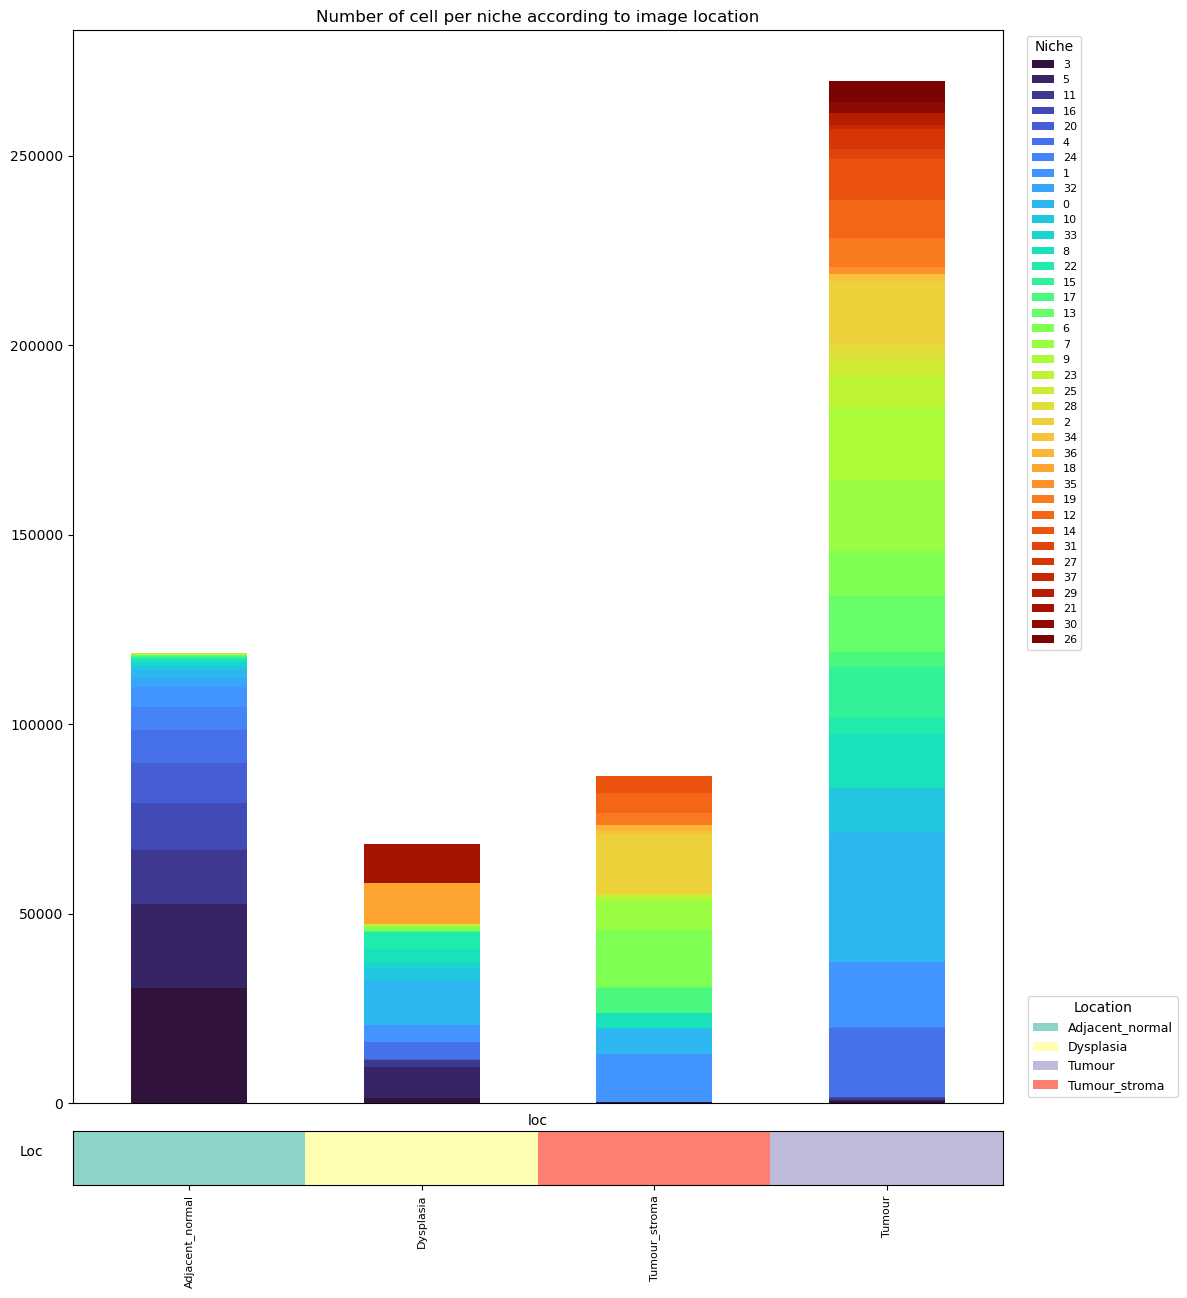

In [789]:
#plot 'Number of cell per niche according to image location

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# -----------------------------
# matrice loc × niche
# -----------------------------
df = loc_count_niche(nodes_by_loc)



df = df.reindex([x for x in order if x in df.index])

# -----------------------------
# figure layout
# -----------------------------
fig = plt.figure(figsize=(12,15))
gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[20, 1],
    hspace=0.05
)

ax = fig.add_subplot(gs[0])
ax_loc = fig.add_subplot(gs[1])

# -----------------------------
# stacked barplot
# -----------------------------

cmap = plt.cm.get_cmap("turbo", nb_niches)
palette_niche = [cmap(i) for i in range(nb_niches)]
df.plot(
    kind="bar",
    stacked=True,
    color=palette_niche,
    ax=ax
)

niche_to_color = {
    niche: cmap(i)
    for i, niche in enumerate(df.columns)
}

# -----------------------------
# couleurs loc
# -----------------------------
locations = df.index.astype(str)

unique_locs = np.unique(locations)
palette = sns.color_palette("Set3", n_colors=len(unique_locs))

loc_to_color = dict(zip(unique_locs, palette))
loc_to_int = {loc: i for i, loc in enumerate(unique_locs)}

loc_ints = np.array([loc_to_int[loc] for loc in locations])

loc_cmap = ListedColormap([loc_to_color[loc] for loc in unique_locs])

# -----------------------------
# barre localisation
# -----------------------------
ax_loc.imshow(
    loc_ints[np.newaxis, :],
    aspect="auto",
    cmap=loc_cmap,
    interpolation="nearest"
)

ax_loc.set_yticks([])
ax_loc.set_ylabel("Loc", rotation=0, labelpad=30)

# -----------------------------
# x labels
# -----------------------------
ax.set_xticklabels([])
ax.tick_params(axis="x", length=0)

ax_loc.set_xticks(np.arange(len(locations)))
ax_loc.set_xticklabels(locations, rotation=90, fontsize=8)

ax_loc.set_xlim(ax.get_xlim())

# -----------------------------
# légende niches
# -----------------------------
cell_legend = ax.legend(
    title="Niche",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=True,
    fontsize=8
)

ax.add_artist(cell_legend)

# -----------------------------
# légende loc
# -----------------------------
region_handles = [
    Patch(facecolor=color, label=loc)
    for loc, color in loc_to_color.items()
]

ax.legend(
    handles=region_handles,
    title = 'Location',
    loc="lower left",
    bbox_to_anchor=(1.02, 0.0),
    frameon=True,
    fontsize=9
)

ax.set_title('Number of cell per niche according to image location')

# -----------------------------
# save + show
# -----------------------------
plt.tight_layout()
if save_bar_plot :
    plt.savefig(bar_plot_dir/'niche_count_loc', bbox_inches="tight")
plt.show()

In [790]:
#je save palette au générée pendant bar plot number cell per niche per loc
import pickle
palette_dir = Path(plot_dir/'palettes')
palette_dir.mkdir(exist_ok=True)

with open(palette_dir/"niche_to_color.pkl", "wb") as f:
    pickle.dump(niche_to_color, f)

In [791]:
#je charge palette  générée au préalable pendant bar plot number cell per niche per loc
import pickle

palette_dir = Path(plot_dir/'palettes')


with open(palette_dir/"niche_to_color.pkl", "rb") as f:
    niche_to_color = pickle.load(f)

## Plots à l'échelle des images (patient-sample)

In [792]:
#définition des fonctions utilisées
import pandas as pd

def loc_count_niche(nodes_by_loc):
    #créer comme une matrice avec en index localisation et en colonne les clusters/niches. 
    # les valeurs de la matrice = nombre de cell dans chaque niche selon loc
    #nodes_by_loc = dict avec différents dataframes pour chaque location et contenant chacuns les nodes
    keys = list(nodes_by_loc.keys())
    df_total = []

    for key in keys:
        df = nodes_by_loc[key]
        
        df_count = df["Niche"].value_counts().to_dict()
        df_count["loc"] = key
        
        df_total.append(df_count)

    return  pd.DataFrame(df_total).set_index("loc").fillna(0)

def sample_count_niche(nodes_by_sample):
     #créer comme une matrice avec en index patient-sample et en colonne les clusters/niches. 
    # les valeurs de la matrice = nombre de cell dans chaque niche selon loc
    #nodes_by_sample = dict avec différents dataframes pour chaque sample et contenant chacuns les nodes
    keys = list(nodes_by_sample.keys())
    df_total = []

    for key in keys:
        df = nodes_by_sample[key]
        
        df_count = df["Niche"].value_counts().to_dict()
        df_count["id"] = key
        
        df_total.append(df_count)

    return  pd.DataFrame(df_total).set_index("id").fillna(0)




Données

In [793]:
#réation dictionnaire avec chaque key est une image et contenant nodes, donc une key = patient-sample
nodes_by_sample = dict(tuple(nodes_cluster_labeled_and_metadata.groupby("id")))

#création Matrice id(patient-sample) / niche avec nombre de cell dans niche par id
df_total_count_sample = sample_count_niche(nodes_by_sample)

#je met les colonnes dans ordre croissant (niches nommées avec des nombres)
df_total_count_sample = df_total_count_sample.reindex(sorted(df_total_count_sample.columns.astype(int)), axis=1)


#data frame avec location by patient-sample que j'utilise dans les plots
df_patient_loc = nodes_cluster_labeled_and_metadata.groupby("id", as_index=False)["location"].first()

#je charge palette  générée au préalable pendant bar plot number cell per niche per loc
import pickle

palette_dir = Path(plot_dir/'palettes')


with open(palette_dir/"niche_to_color.pkl", "rb") as f:
    niche_to_color = pickle.load(f)

### Bar plot

Paramètres

In [794]:




if without_normal == False:
    #je charge palette  générée au préalable pendant bar plot number cell per niche per loc
    import pickle
    palette_dir = Path(plot_dir/'palettes')

    with open(palette_dir/"niche_to_color.pkl", "rb") as f:
        niche_to_color = pickle.load(f)


/tmp/ipykernel_17497/272091542.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


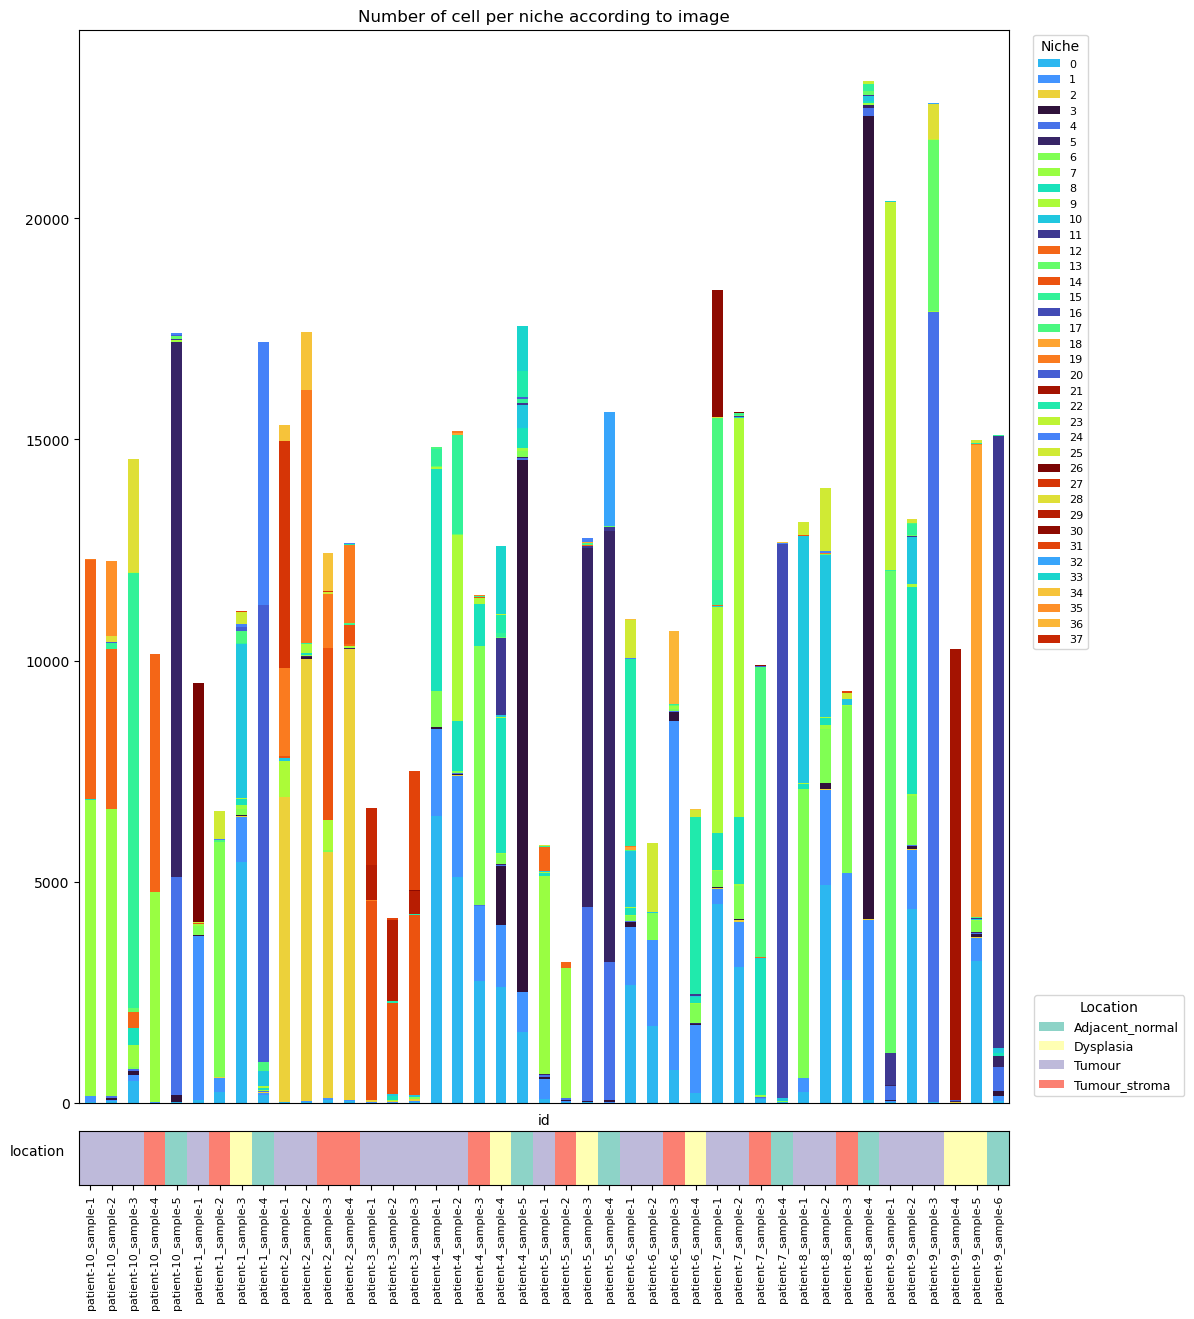

In [795]:
#Bar plot Number of cell per niche according to image'
# JE réuse palette du plot juste au dessus qui permet de voir couleurs vers le rouge associées à tumeur par exemple pour donner sens aux couleurs


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# -----------------------------
# matrice patient × niche
# -----------------------------
df = sample_count_niche(nodes_by_sample)
df = df.reindex(sorted(df.columns.astype(int)), axis=1)

df = df.sort_index()

df["location"] = df_patient_loc.set_index("id")["location"].reindex(df.index)
df_niche = df.drop(columns=["location"])
locations = df["location"].astype(str)


# -----------------------------
# figure layout
# -----------------------------
fig = plt.figure(figsize=(12,15))
gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[20, 1],
    hspace=0.05
)

ax = fig.add_subplot(gs[0])
ax_loc = fig.add_subplot(gs[1])

# -----------------------------
# stacked barplot
# -----------------------------

palette_niche = [
    niche_to_color[int(niche)]
    for niche in df_niche.columns
]
df_niche.plot(
    kind="bar",
    stacked=True,
    color=palette_niche,
    ax=ax
)

# -----------------------------
# couleurs patient
# -----------------------------


unique_locs = np.unique(locations)
palette = sns.color_palette("Set3", n_colors=len(unique_locs))

loc_to_color = dict(zip(unique_locs, palette))
loc_to_int = {loc: i for i, loc in enumerate(unique_locs)}

loc_ints = np.array([loc_to_int[loc] for loc in locations])

loc_cmap = ListedColormap([loc_to_color[loc] for loc in unique_locs])

# -----------------------------
# barre patient
# -----------------------------
ax_loc.imshow(
    loc_ints[np.newaxis, :],
    aspect="auto",
    cmap=loc_cmap,
    interpolation="nearest"
)

ax_loc.set_yticks([])
ax_loc.set_ylabel("location", rotation=0, labelpad=30)

# -----------------------------
# x labels
# -----------------------------
ax.set_xticklabels([])
ax.tick_params(axis="x", length=0)

patient = df_niche.index.astype(str)
ax_loc.set_xticks(np.arange(len(patient)))
ax_loc.set_xticklabels(patient, rotation=90, fontsize=8)

ax_loc.set_xlim(ax.get_xlim())

# -----------------------------
# légende niches
# -----------------------------
cell_legend = ax.legend(
    title="Niche",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=True,
    fontsize=8
)

ax.add_artist(cell_legend)

# -----------------------------
# légende loc
# -----------------------------
region_handles = [
    Patch(facecolor=color, label=loc)
    for loc, color in loc_to_color.items()
]

ax.legend(
    handles=region_handles,
    title = 'Location',
    loc="lower left",
    bbox_to_anchor=(1.02, 0.0),
    frameon=True,
    fontsize=9
)




ax.set_title('Number of cell per niche according to image')

# -----------------------------
# save + show
# -----------------------------
plt.tight_layout()
if save_bar_plot == True:
    plt.savefig(bar_plot_dir/'barplot_niche_count_per_image_colored_by_cell-per-niche-loc-barplot_palette', bbox_inches="tight")
plt.show()

/tmp/ipykernel_17497/2538983840.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("turbo", nb_niches)
/tmp/ipykernel_17497/2538983840.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


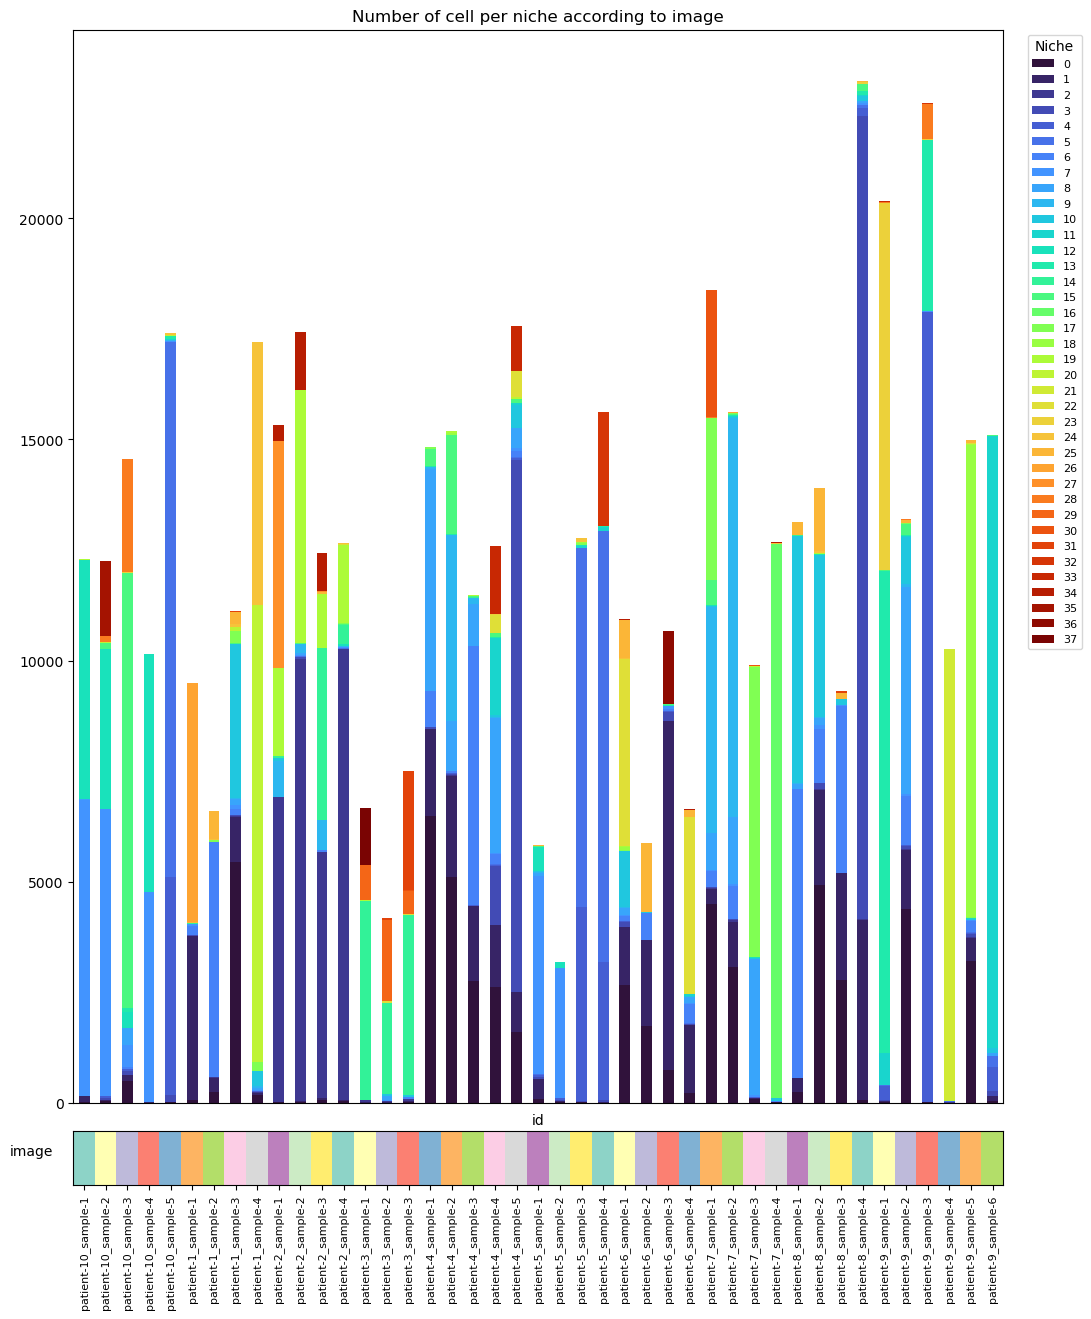

In [796]:
#Je n'utilise pas de palette préalable
# nombre de niche, pour le calcul nombre couleur palette


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# -----------------------------
# matrice patient × niche
# -----------------------------
df = sample_count_niche(nodes_by_sample)
df = df.sort_index()
df = df.reindex(sorted(df.columns.astype(int)), axis=1)



# -----------------------------
# figure layout
# -----------------------------
fig = plt.figure(figsize=(12,15))
gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[20, 1],
    hspace=0.05
)

ax = fig.add_subplot(gs[0])
ax_loc = fig.add_subplot(gs[1])

# -----------------------------
# stacked barplot
# -----------------------------

#créer propre palette
cmap = plt.cm.get_cmap("turbo", nb_niches)
palette = [cmap(i) for i in range(nb_niches)]

df.plot(
    kind="bar",
    stacked=True,
    color=palette,
    ax=ax
)

# -----------------------------
# couleurs loc
# -----------------------------
locations = df.index.astype(str)

unique_locs = np.unique(locations)
palette = sns.color_palette("Set3", n_colors=len(unique_locs))

loc_to_color = dict(zip(unique_locs, palette))
loc_to_int = {loc: i for i, loc in enumerate(unique_locs)}

loc_ints = np.array([loc_to_int[loc] for loc in locations])

loc_cmap = ListedColormap([loc_to_color[loc] for loc in unique_locs])

# -----------------------------
# barre localisation
# -----------------------------
ax_loc.imshow(
    loc_ints[np.newaxis, :],
    aspect="auto",
    cmap=loc_cmap,
    interpolation="nearest"
)

ax_loc.set_yticks([])
ax_loc.set_ylabel("image", rotation=0, labelpad=30)

# -----------------------------
# x labels
# -----------------------------
ax.set_xticklabels([])
ax.tick_params(axis="x", length=0)

ax_loc.set_xticks(np.arange(len(locations)))
ax_loc.set_xticklabels(locations, rotation=90, fontsize=8)

ax_loc.set_xlim(ax.get_xlim())

# -----------------------------
# légende niches
# -----------------------------
ax.legend(
    title="Niche",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=True,
    fontsize=8
)

#ax.add_artist(cell_legend)



ax.set_title('Number of cell per niche according to image')

# -----------------------------
# save + show
# -----------------------------
plt.tight_layout()
if save_bar_plot == True:
    plt.savefig(bar_plot_dir/'barplot_niche_count_per_image_colored_by_niche_indice', bbox_inches="tight")
plt.show()

### PCA and umap 

#### Initialisation

In [797]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


In [798]:
def sample_count_niche(nodes_by_sample):
     #créer comme une matrice avec en index patient-sample et en colonne les clusters/niches. 
    # les valeurs de la matrice = nombre de cell dans chaque niche selon loc
    #nodes_by_sample = dict avec différents dataframes pour chaque sample et contenant chacuns les nodes
    keys = list(nodes_by_sample.keys())
    df_total = []

    for key in keys:
        df = nodes_by_sample[key]
        
        df_count = df["Niche"].value_counts().to_dict()
        df_count["id"] = key
        
        df_total.append(df_count)

    return  pd.DataFrame(df_total).set_index("id").fillna(0)



In [799]:
#data frame avec location by patient-sample que j'utilise dans les plots
df_patient_loc = nodes_cluster_labeled_and_metadata.groupby("id", as_index=False)["location"].first()

#dictionnaire avec chaque key = une image = patient-sample et dedans il y a les nodes
nodes_by_sample = dict(tuple(nodes_cluster_labeled_and_metadata.groupby("id")))
#création Matrice id(patient-sample) / niche avec nombre de cell dans niche par id

df_total_count_sample = sample_count_niche(nodes_by_sample)
#je met les colonnes dans ordre croissant (niches nommées avec des nombres)
df_total_count_sample = df_total_count_sample.reindex(sorted(df_total_count_sample.columns.astype(int)), axis=1)

In [800]:
df_total_count_sample.head()

,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
id,,,,,,,,,,,,,,,,,,,,,
patient-10_sample-1,24.0,127,0.0,0.0,5.0,0.0,0.0,6701.0,6.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
patient-10_sample-2,30.0,33,4.0,43.0,31.0,12.0,1.0,6479.0,6.0,0.0,...,133.0,0.0,0.0,0.0,0.0,0.0,0.0,1688.0,0.0,0.0
patient-10_sample-3,483.0,141,7.0,92.0,35.0,5.0,49.0,493.0,388.0,1.0,...,2548.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0
patient-10_sample-4,1.0,8,0.0,0.0,3.0,0.0,0.0,4762.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0
patient-10_sample-5,5.0,17,2.0,147.0,4926.0,12113.0,0.0,16.0,1.0,13.0,...,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [801]:
# je prépare les données pour les réductions PCA et umap prenant en compte assort et niche
# -----------------------------
# matrice patient × niche
# -----------------------------
df = sample_count_niche(nodes_by_sample)


#normalisation par ligne/patient
if normalize and without_normal == False :
    df = df.div(df.sum(axis=1), axis=0)
df = df.reindex(sorted(df.columns.astype(int)), axis=1)

if normalize and without_normal:
    df["location"] = df_patient_loc.set_index("id")["location"].reindex(df.index)
    df = df[df['location'] != 'Adjacent_normal']
    data = df.copy()
    df = df.drop(columns=["location"])
    locations = data["location"].astype(str)

    #normalisation par ligne/patient
    df = df.div(df.sum(axis=1), axis=0)

if normalize == False and without_normal:
    df["location"] = df_patient_loc.set_index("id")["location"].reindex(df.index)
    df = df[df['location'] != 'Adjacent_normal']
    data = df.copy()
    df = df.drop(columns=["location"])
    locations = data["location"].astype(str)


# récup stats data sans le générer

stats_data = pd.read_parquet(stats_data_dir)
stats_data["id"] = (
    stats_data["id"]
    .map(
        lambda x: re.sub(r'(\D)0+(\d+)', r'\1\2', x)
    )
)


stats_data_Z = stats_data


colonnes_Z = [col for col in stats_data.columns if col.endswith("Z")]
stats_data_Z = stats_data[["id"] + colonnes_Z]
stats_data_Z  = stats_data_Z .drop(columns ="assort Z")
if drop_homo_assort == True :
    assort_cols = stats_data_Z.columns

    same_cell_cols = [
        col for col in assort_cols
        if " - " in col
        and col.replace(" Z", "").split(" - ")[0].strip()
        == col.replace(" Z", "").split(" - ")[1].strip()
    ]

    stats_data_Z.loc[:, same_cell_cols] = np.nan

stats_data_Z = stats_data_Z.set_index('id')
X = stats_data_Z.copy()
X = X.replace([np.inf, -np.inf], np.nan)
#X = X.fillna(0)
X_trans = np.sign(X) * np.log1p(np.abs(X))

#data_for_reduction = stats_data_Z.copy()
data_for_reduction = X_trans.copy()
data_for_reduction = data_for_reduction.join(df, how='inner')



#### PCA and umap

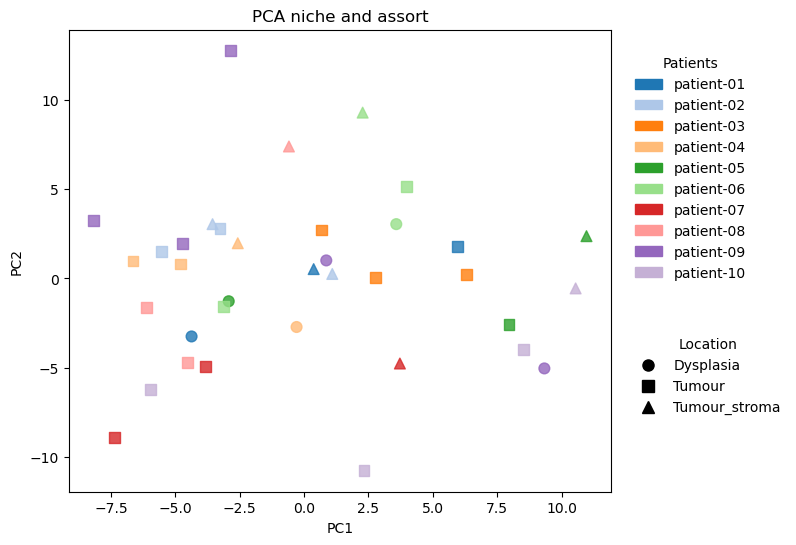

In [802]:
#PCA niche and assort

X = data_for_reduction.copy()


#je rajoute colonne id(patient-sample), patient et sample
X = data_for_reduction.copy()
X['id']= X.index.astype(str)
X[["patient", "sample"]] = X["id"].str.extract(
    r"patient-(\d+)_sample-(\d+)"
)

X["patient"] = X["patient"].astype(int)
X["sample"] = X["sample"].astype(int)

# Ajout de la localisation
location_df = (
    nodes_cluster_labeled_and_metadata[["id", "location"]]
    .drop_duplicates("id")
)
X = X.reset_index(drop=True)
X = X.merge(location_df, on="id", how="left")

#je sépare données patient et données PCA

patients = X["patient"].astype(str)
locations = X["location"].copy()
X = X.drop(columns=["patient","id","sample","location"])


#markers pour les locations
marker_list = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X', '*']

unique_locations = sorted(locations.unique())

location_to_marker = {
    loc: marker_list[i % len(marker_list)]
    for i, loc in enumerate(unique_locations)
}

#je recup patients et samples pour légende
ids = X.index.astype(str)

#je prépare données
X.columns = X.columns.astype(str)



X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)
X = StandardScaler().fit_transform(X)
#X = np.log1p(X)



pca = PCA(n_components=2)
coords = pca.fit_transform(X)




#couleurs patient
unique_patients = sorted(
    patients.unique(),
    key=lambda x: int(x.split("-")[-1])
)
patient_labels = {
    p: f"patient-{int(p):02d}"
    for p in unique_patients
}

palette = sns.color_palette("tab20", len(unique_patients))

patient_to_color = dict(zip(unique_patients, palette))
colors = patients.map(patient_to_color)



plt.figure(figsize=(7,6))

for loc in unique_locations:

    mask = locations == loc

    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=colors[mask],
        marker=location_to_marker[loc],
        s=60,
        alpha=0.8
    )



# -----------------------------
# légende patients
# -----------------------------

patient_handles = [
    mpatches.Patch(
        color=patient_to_color[p],
        label=patient_labels[p]   # ici le mapping correct
    )
    for p in unique_patients
]


patient_legend = plt.legend(
    handles=patient_handles,
    title="Patients",
    loc="center left",
    bbox_to_anchor=(1.02, 0.7),
    frameon=False
)

plt.gca().add_artist(patient_legend)

#texte patient-sample sur plot
#for i, txt in enumerate(ids):
    #plt.text(
       # coords[i,0],
        #coords[i,1],
      #  txt,
       # fontsize=6,
       # alpha=0.7
   # )
location_handles = [
    plt.Line2D(
        [0], [0],
        marker=location_to_marker[loc],
        color="black",
        linestyle="",
        markersize=8,
        label=loc
    )
    for loc in unique_locations
]

plt.legend(
    handles=location_handles,
    title="Location",
    loc="center left",
    bbox_to_anchor=(1.02, 0.25),
    frameon=False
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA niche and assort")

if save :
    if without_normal and drop_homo_assort :
        plt.savefig(plot_dir/'PCA_niche_and_assort_no_homo_without_adjacent_normal', bbox_inches="tight")
    if without_normal and drop_homo_assort == False:
         plt.savefig(plot_dir/'PCA_niche_and_assort_without_adjacent_normal', bbox_inches="tight")
    if without_normal == False and drop_homo_assort :
        plt.savefig(plot_dir/'PCA_niche_and_assort_no_homo', bbox_inches="tight")
    if without_normal == False and drop_homo_assort == False :
        plt.savefig(plot_dir/'PCA_niche_and_assort', bbox_inches="tight")
   

plt.show()

/home/mohamed.tahounza/miniconda3/envs/mosna/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


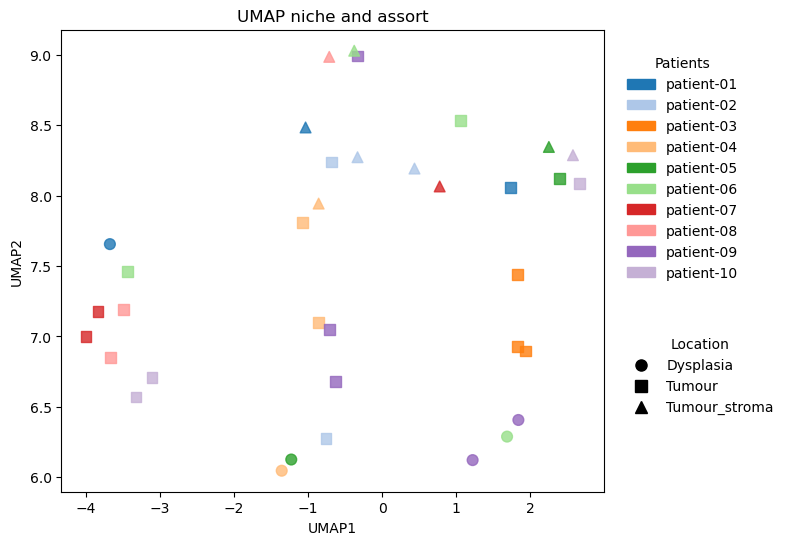

In [803]:
# umap niche and assort
X = data_for_reduction.copy()

X["id"] = X.index.astype(str)
X[["patient", "sample"]] = X["id"].str.extract(
    r"patient-(\d+)_sample-(\d+)"
)

X["patient"] = X["patient"].astype(int)
X["sample"] = X["sample"].astype(int)

# -------------------------
# LOCATION (ajout)
# -------------------------
location_df = (
    nodes_cluster_labeled_and_metadata[["id", "location"]]
    .drop_duplicates("id")
)
X = X.reset_index(drop=True)
X = X.merge(location_df, on="id", how="left")

# -------------------------
# labels
# -------------------------
patients = X["patient"].astype(str)
locations = X["location"].fillna("Unknown").astype(str)

# -------------------------
# drop metadata
# -------------------------
X = X.drop(columns=["patient", "id", "sample", "location"])

# -------------------------
# preprocessing
# -------------------------
X.columns = X.columns.astype(str)
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

ids = X.index.astype(str)

#X = StandardScaler().fit_transform(X)

# -------------------------
# UMAP
# -------------------------
reducer = umap.UMAP(
    n_neighbors=4,
    min_dist=0,
    random_state=42
)

coords = reducer.fit_transform(X)

# -------------------------
# patients colors
# -------------------------
unique_patients = sorted(
    patients.unique(),
    key=lambda x: int(x)
)

patient_labels = {
    p: f"patient-{int(p):02d}"
    for p in unique_patients
}

palette = sns.color_palette("tab20", len(unique_patients))
patient_to_color = dict(zip(unique_patients, palette))
colors = patients.map(patient_to_color)

# -------------------------
# locations markers
# -------------------------
marker_list = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X', '*']

unique_locations = sorted(locations.unique())

location_to_marker = {
    loc: marker_list[i % len(marker_list)]
    for i, loc in enumerate(unique_locations)
}

# -------------------------
# plot
# -------------------------
plt.figure(figsize=(7,6))

for loc in unique_locations:
    mask = (locations == loc).values

    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=colors[mask],
        marker=location_to_marker[loc],
        s=60,
        alpha=0.8
    )

patient_handles = [
    mpatches.Patch(
        color=patient_to_color[p],
        label=patient_labels[p]   # ici le mapping correct
    )
    for p in unique_patients
]


patient_legend = plt.legend(
    handles=patient_handles,
    title="Patients",
    loc="center left",
    bbox_to_anchor=(1.02, 0.7),
    frameon=False
)

plt.gca().add_artist(patient_legend)

#texte patient-sample sur plot
#for i, txt in enumerate(ids):
    #plt.text(
       # coords[i,0],
        #coords[i,1],
      #  txt,
       # fontsize=6,
       # alpha=0.7
   # )
location_handles = [
    plt.Line2D(
        [0], [0],
        marker=location_to_marker[loc],
        color="black",
        linestyle="",
        markersize=8,
        label=loc
    )
    for loc in unique_locations
]

plt.legend(
    handles=location_handles,
    title="Location",
    loc="center left",
    bbox_to_anchor=(1.02, 0.25),
    frameon=False
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP niche and assort")

# -------------------------
# SAVE (inchangé)
# -------------------------
if save :
    if without_normal and drop_homo_assort :
        plt.savefig(plot_dir/'umap_niche_and_assort_no_homo_without_adjacent_normal', bbox_inches="tight")
    if without_normal and drop_homo_assort == False:
         plt.savefig(plot_dir/'umap_niche_and_assort_without_adjacent_normal', bbox_inches="tight")
    if without_normal == False and drop_homo_assort :
        plt.savefig(plot_dir/'umap_niche_and_assort_no_homo', bbox_inches="tight")
    if without_normal == False and drop_homo_assort == False :
        plt.savefig(plot_dir/'umap_niche_and_assort', bbox_inches="tight")

plt.show()

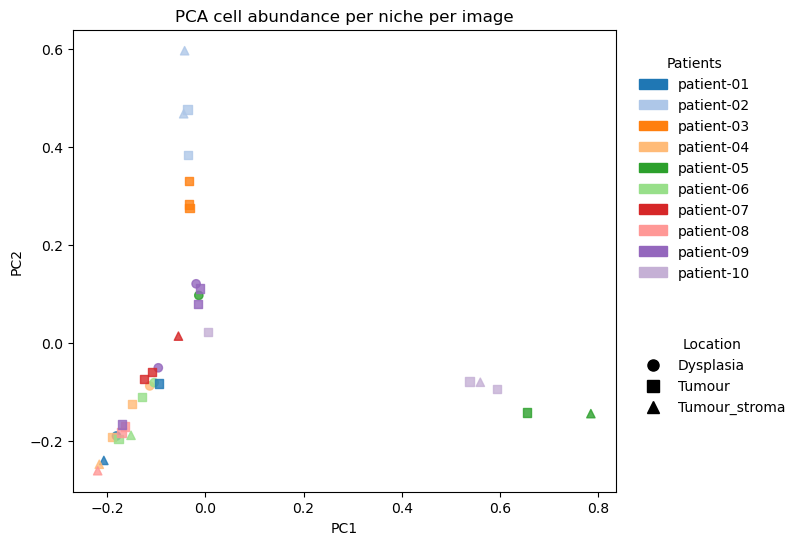

In [804]:
# -----------------------------
# PCA cell abundance per niche per image
# -----------------------------

X = df_total_count_sample.copy()

df = X.copy()

# -----------------------------
# normalization
# -----------------------------
if normalize and without_normal == False:
    df = df.div(df.sum(axis=1), axis=0)
    df = df.reindex(sorted(df.columns.astype(int)), axis=1)

if normalize and without_normal:
    df["location"] = df_patient_loc.set_index("id")["location"].reindex(df.index)
    df = df[df["location"] != "Adjacent_normal"]
    locations = df["location"].astype(str)
    df = df.drop(columns=["location"])
    df = df.div(df.sum(axis=1), axis=0)

if normalize == False and without_normal:
    df["location"] = df_patient_loc.set_index("id")["location"].reindex(df.index)
    df = df[df["location"] != "Adjacent_normal"]
    locations = df["location"].astype(str)
    df = df.drop(columns=["location"])

# -----------------------------
# metadata
# -----------------------------
X = df.copy()

X["id"] = X.index.astype(str)
X[["patient", "sample"]] = X["id"].str.extract(
    r"patient-(\d+)_sample-(\d+)"
)

X["patient"] = X["patient"].astype(int)
X["sample"] = X["sample"].astype(int)

location_df = (
    nodes_cluster_labeled_and_metadata[["id", "location"]]
    .drop_duplicates("id")
)

X = X.reset_index(drop=True)

X = X.merge(location_df, on="id", how="left")

patients = X["patient"].astype(str)
locations = X["location"].fillna("Unknown").astype(str)

# -----------------------------
# PCA matrix
# -----------------------------
X_feat = X.drop(columns=["patient", "id", "sample", "location"])
X_feat.columns = X_feat.columns.astype(str)

X_feat = X_feat.replace([np.inf, -np.inf], np.nan).fillna(0)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_feat)

# -----------------------------
# colors (patients)
# -----------------------------
unique_patients = sorted(patients.unique(), key=lambda x: int(x))

patient_labels = {
    p: f"patient-{int(p):02d}"
    for p in unique_patients
}

palette = sns.color_palette("tab20", len(unique_patients))
patient_to_color = dict(zip(unique_patients, palette))
colors = patients.map(patient_to_color)

# -----------------------------
# markers (locations)
# -----------------------------
marker_list = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X', '*']

unique_locations = sorted(locations.unique())

location_to_marker = {
    loc: marker_list[i % len(marker_list)]
    for i, loc in enumerate(unique_locations)
}

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(7,6))

for loc in unique_locations:
    mask = (locations == loc).values

    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=colors[mask],
        marker=location_to_marker[loc],
        alpha=0.8
    )

# -----------------------------
# LEGEND PATIENTS
# -----------------------------
patient_handles = [
    mpatches.Patch(
        color=patient_to_color[p],
        label=patient_labels[p]
    )
    for p in unique_patients
]

patient_legend = plt.legend(
    handles=patient_handles,
    title="Patients",
    loc="center left",
    bbox_to_anchor=(1.02, 0.7),
    frameon=False
)

plt.gca().add_artist(patient_legend)

# -----------------------------
# LEGEND LOCATION
# -----------------------------
location_handles = [
    plt.Line2D(
        [0], [0],
        marker=location_to_marker[loc],
        color="black",
        linestyle="",
        markersize=8,
        label=loc
    )
    for loc in unique_locations
]

plt.legend(
    handles=location_handles,
    title="Location",
    loc="center left",
    bbox_to_anchor=(1.02, 0.25),
    frameon=False
)

# -----------------------------
# LABELS
# -----------------------------
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA cell abundance per niche per image")

# -----------------------------
# SAVE (UNCHANGED)
# -----------------------------
if save:
    if without_normal:
        plt.savefig(
            plot_dir / "PCA_cell_abundance_per_niche_per_image_without_adjacent_normal",
            bbox_inches="tight"
        )
    else:
        plt.savefig(
            plot_dir / "PCA_cell_abundance_per_niche_per_image",
            bbox_inches="tight"
        )

plt.show()

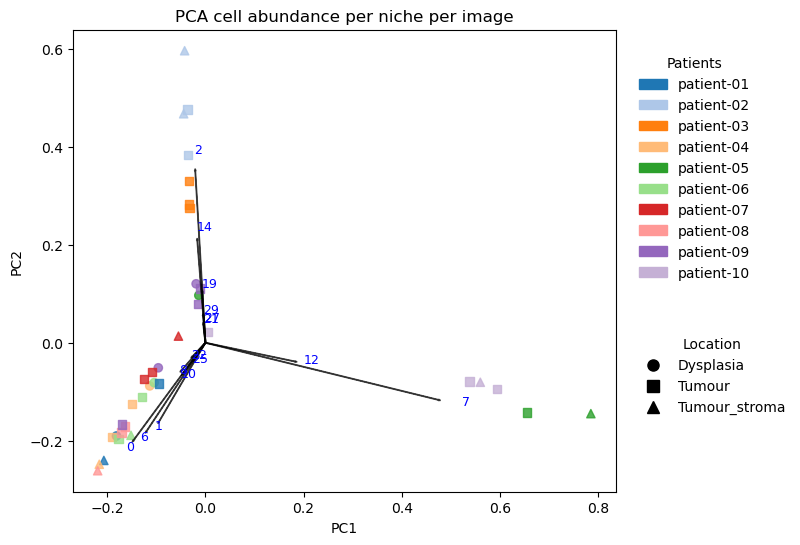

In [805]:
# -----------------------------
# PCA cell abundance per niche per image
# -----------------------------

X = df_total_count_sample.copy()

df = X.copy()

# -----------------------------
# normalization
# -----------------------------
if normalize and without_normal == False:
    df = df.div(df.sum(axis=1), axis=0)
    df = df.reindex(sorted(df.columns.astype(int)), axis=1)

if normalize and without_normal:
    df["location"] = df_patient_loc.set_index("id")["location"].reindex(df.index)
    df = df[df["location"] != "Adjacent_normal"]
    locations = df["location"].astype(str)
    df = df.drop(columns=["location"])
    df = df.div(df.sum(axis=1), axis=0)

if normalize == False and without_normal:
    df["location"] = df_patient_loc.set_index("id")["location"].reindex(df.index)
    df = df[df["location"] != "Adjacent_normal"]
    locations = df["location"].astype(str)
    df = df.drop(columns=["location"])

# -----------------------------
# metadata
# -----------------------------
X = df.copy()

X["id"] = X.index.astype(str)
X[["patient", "sample"]] = X["id"].str.extract(
    r"patient-(\d+)_sample-(\d+)"
)

X["patient"] = X["patient"].astype(int)
X["sample"] = X["sample"].astype(int)

# IMPORTANT: location join SANS reset_index
location_df = (
    nodes_cluster_labeled_and_metadata[["id", "location"]]
    .drop_duplicates("id")
)
X = X.reset_index(drop=True)
X = X.merge(location_df, on="id", how="left")

patients = X["patient"].astype(str)
locations = X["location"].fillna("Unknown").astype(str)

# -----------------------------
# PCA matrix
# -----------------------------

X_feat = X.drop(columns=["patient", "id", "sample", "location"])
X_feat.columns = X_feat.columns.astype(str)

X_feat = X_feat.replace([np.inf, -np.inf], np.nan).fillna(0)

feature_names = X_feat.columns

pca = PCA(n_components=2)
coords = pca.fit_transform(X_feat)

# -----------------------------
# colors (patients)
# -----------------------------
unique_patients = sorted(patients.unique(), key=lambda x: int(x))

patient_labels = {
    p: f"patient-{int(p):02d}"
    for p in unique_patients
}

palette = sns.color_palette("tab20", len(unique_patients))
patient_to_color = dict(zip(unique_patients, palette))
colors = patients.map(patient_to_color)

# -----------------------------
# loadings (top vectors)
# -----------------------------
loadings = pca.components_.T

scale = 0.7 * np.max(np.linalg.norm(coords, axis=1))

importance = np.linalg.norm(loadings[:, :2], axis=1)
top_idx = np.argsort(importance)[-15:]

# -----------------------------
# markers (locations)
# -----------------------------
marker_list = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X', '*']

unique_locations = sorted(locations.unique())

location_to_marker = {
    loc: marker_list[i % len(marker_list)]
    for i, loc in enumerate(unique_locations)
}

# -----------------------------
# PLOT (ONE FIGURE ONLY)
# -----------------------------
plt.figure(figsize=(7,6))

# points by location
for loc in unique_locations:
    mask = (locations == loc).values

    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=colors[mask],
        marker=location_to_marker[loc],
        alpha=0.8
    )

# vectors (PCA loadings)
for i in top_idx:
    plt.arrow(
        0, 0,
        loadings[i, 0] * scale,
        loadings[i, 1] * scale,
        color="black",
        alpha=0.7
    )

    plt.text(
        loadings[i, 0] * scale * 1.1,
        loadings[i, 1] * scale * 1.1,
        feature_names[i],
        fontsize=9,
        color="blue"
    )

# -----------------------------
# LEGEND PATIENTS
# -----------------------------
patient_handles = [
    mpatches.Patch(
        color=patient_to_color[p],
        label=patient_labels[p]
    )
    for p in unique_patients
]

patient_legend = plt.legend(
    handles=patient_handles,
    title="Patients",
    loc="center left",
    bbox_to_anchor=(1.02, 0.7),
    frameon=False
)

plt.gca().add_artist(patient_legend)

# -----------------------------
# LEGEND LOCATION
# -----------------------------
location_handles = [
    plt.Line2D(
        [0], [0],
        marker=location_to_marker[loc],
        color="black",
        linestyle="",
        markersize=8,
        label=loc
    )
    for loc in unique_locations
]

plt.legend(
    handles=location_handles,
    title="Location",
    loc="center left",
    bbox_to_anchor=(1.02, 0.25),
    frameon=False
)

# -----------------------------
# LABELS
# -----------------------------
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA cell abundance per niche per image")

# -----------------------------
# SAVE (UNCHANGED)
# -----------------------------
if save:
    if without_normal:
        plt.savefig(plot_dir / "vectors_PCA_cell_abundance_per_niche_per_image_without_adjacent_normal",
                    bbox_inches="tight")
    else:
        plt.savefig(plot_dir / "vectors_PCA_cell_abundance_per_niche_per_image",
                    bbox_inches="tight")

plt.show()

/home/mohamed.tahounza/miniconda3/envs/mosna/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Figure size 700x600 with 0 Axes>

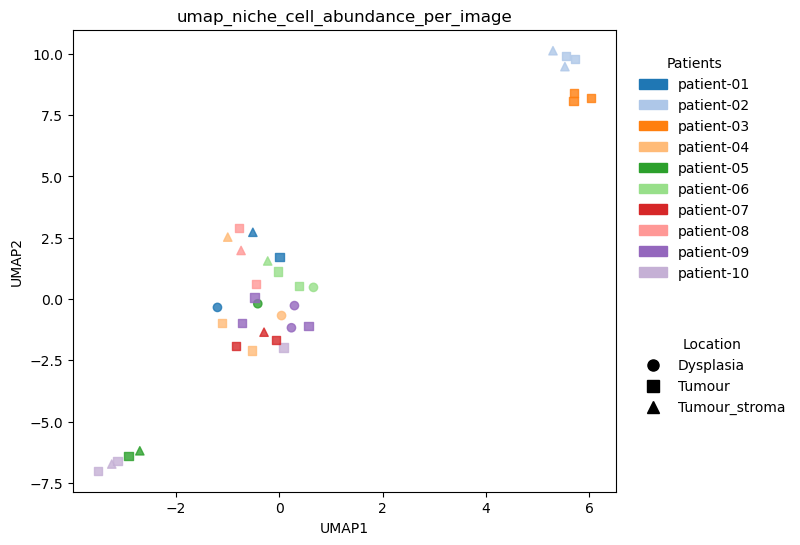

In [806]:
#umap cell anbundance per niche  per patient-sample

X = df_total_count_sample.copy()

# -----------------------------
# matrice patient × niche
# -----------------------------
df = X.copy()


#normalisation par ligne/patient
if normalize and without_normal == False :
    df = df.div(df.sum(axis=1), axis=0)
    df = df.reindex(sorted(df.columns.astype(int)), axis=1)

if normalize and without_normal:
    df["location"] = df_patient_loc.set_index("id")["location"].reindex(df.index)
    df = df[df['location'] != 'Adjacent_normal']
    data = df.copy()
    df = df.drop(columns=["location"])
    locations = data["location"].astype(str)

    #normalisation par ligne/patient
    df = df.div(df.sum(axis=1), axis=0)

if normalize == False and without_normal:
    df["location"] = df_patient_loc.set_index("id")["location"].reindex(df.index)
    df = df[df['location'] != 'Adjacent_normal']
    data = df.copy()
    df = df.drop(columns=["location"])
    locations = data["location"].astype(str)

#X = np.log1p(X)

X = df.copy()

X['id']= X.index.astype(str)
X[["patient", "sample"]] = X["id"].str.extract(
    r"patient-(\d+)_sample-(\d+)"
)

X["patient"] = X["patient"].astype(int)
X["sample"] = X["sample"].astype(int)

#je sépare données patient et données umap

# -----------------------------
# LOCATION (AJOUT)
# -----------------------------
location_df = (
    nodes_cluster_labeled_and_metadata[["id", "location"]]
    .drop_duplicates("id")
)
X = X.reset_index(drop=True)
X = X.merge(location_df, on="id", how="left")

# -----------------------------
# LABELS AVANT DROP
# -----------------------------
patients = X["patient"].astype(str)
locations = X["location"].fillna("Unknown").astype(str)


X = X.drop(columns=["patient","id","sample","location"])
#X = X.select_dtypes(include=[np.number])
#X = X.div(X.sum(axis=1), axis=0)

#je prépapre données
X.columns = X.columns.astype(str)


#normalisation par ligne/patient
#heatmap_data = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)
#X = StandardScaler().fit_transform(X)

#X = StandardScaler().fit_transform(X)
#je recup patients et samples pour légende


reducer = umap.UMAP(
    n_neighbors=5,
    min_dist=0.2,
    random_state=42
)

coords = reducer.fit_transform(X)
#couleurs patient





plt.figure(figsize=(7,6))


unique_patients = sorted(
    patients.unique(),
    key=lambda x: int(x.split("-")[-1])
)
patient_labels = {
    p: f"patient-{int(p):02d}"
    for p in unique_patients
}

palette = sns.color_palette("tab20", len(unique_patients))

patient_to_color = dict(zip(unique_patients, palette))
colors = patients.map(patient_to_color)

# -----------------------------
# MARKERS (locations)
# -----------------------------
marker_list = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X', '*']

unique_locations = sorted(locations.unique())

location_to_marker = {
    loc: marker_list[i % len(marker_list)]
    for i, loc in enumerate(unique_locations)
}

# -----------------------------
# PLOT (split by location)
# -----------------------------
plt.figure(figsize=(7,6))

for loc in unique_locations:
    mask = (locations == loc).values

    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=colors[mask],
        marker=location_to_marker[loc],
        alpha=0.8
    )

# -----------------------------
# LEGEND PATIENTS
# -----------------------------
patient_handles = [
    mpatches.Patch(
        color=patient_to_color[p],
        label=patient_labels[p]   # ici le mapping correct
    )
    for p in unique_patients
]


patient_legend = plt.legend(
    handles=patient_handles,
    title="Patients",
    loc="center left",
    bbox_to_anchor=(1.02, 0.7),
    frameon=False
)

plt.gca().add_artist(patient_legend)

#texte patient-sample sur plot
#for i, txt in enumerate(ids):
    #plt.text(
       # coords[i,0],
        #coords[i,1],
      #  txt,
       # fontsize=6,
       # alpha=0.7
   # )
location_handles = [
    plt.Line2D(
        [0], [0],
        marker=location_to_marker[loc],
        color="black",
        linestyle="",
        markersize=8,
        label=loc
    )
    for loc in unique_locations
]

plt.legend(
    handles=location_handles,
    title="Location",
    loc="center left",
    bbox_to_anchor=(1.02, 0.25),
    frameon=False
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("umap_niche_cell_abundance_per_image")

if save :
    if without_normal :
        plt.savefig(plot_dir/ "umap_niche_cell_abundance_per_image_without_adjacent_normal", bbox_inches="tight")
    else :
        plt.savefig(plot_dir/ "umap_niche_cell_abundance_per_image", bbox_inches="tight")

plt.show()



/home/mohamed.tahounza/miniconda3/envs/mosna/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


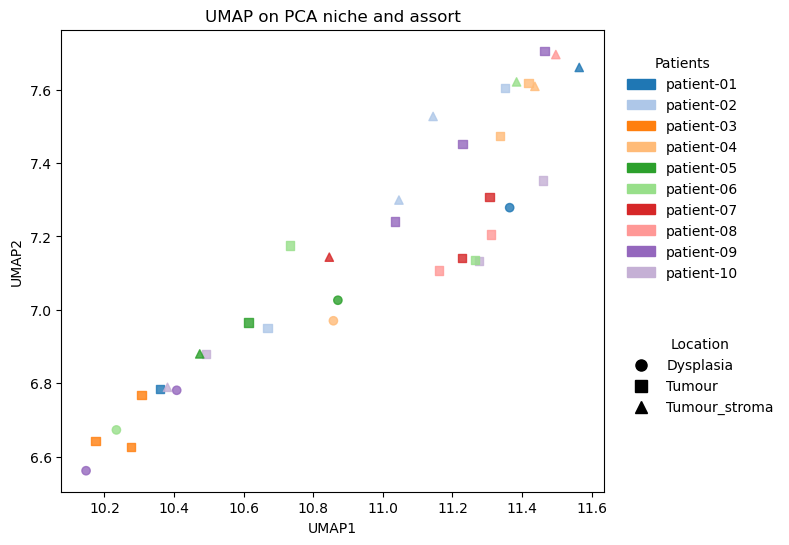

In [807]:
import umap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# DATA PREP
# -----------------------------
X = data_for_reduction.copy()

X["id"] = X.index.astype(str)
X[["patient", "sample"]] = X["id"].str.extract(
    r"patient-(\d+)_sample-(\d+)"
)

X["patient"] = X["patient"].astype(int)
X["sample"] = X["sample"].astype(int)

# -----------------------------
# LOCATION (AJOUT)
# -----------------------------
location_df = (
    nodes_cluster_labeled_and_metadata[["id", "location"]]
    .drop_duplicates("id")
)
X = X.reset_index(drop=True)
X = X.merge(location_df, on="id", how="left")

# -----------------------------
# LABELS AVANT DROP
# -----------------------------
patients = X["patient"].astype(str)
locations = X["location"].fillna("Unknown").astype(str)

# -----------------------------
# DROP METADATA
# -----------------------------
ids = X.index.astype(str)

X = X.drop(columns=["patient", "id", "sample", "location"])

# -----------------------------
# NUMERIC PREPROCESSING
# -----------------------------
X.columns = X.columns.astype(str)
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
#X = StandardScaler().fit_transform(X)
#X = StandardScaler().fit_transform(X)

# -----------------------------
# PCA + UMAP
# -----------------------------
pca = PCA(n_components=23)
coords = pca.fit_transform(X)

reducer = umap.UMAP(
    n_neighbors=5,
    min_dist=0,
    random_state=42,
    n_components = 15
)

coords = reducer.fit_transform(coords)

# -----------------------------
# COLORS (patients)
# -----------------------------
unique_patients = sorted(
    patients.unique(),
    key=lambda x: int(x)
)

patient_labels = {
    p: f"patient-{int(p):02d}"
    for p in unique_patients
}

palette = sns.color_palette("tab20", len(unique_patients))
patient_to_color = dict(zip(unique_patients, palette))
colors = patients.map(patient_to_color)

# -----------------------------
# MARKERS (locations)
# -----------------------------
marker_list = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X', '*']

unique_locations = sorted(locations.unique())

location_to_marker = {
    loc: marker_list[i % len(marker_list)]
    for i, loc in enumerate(unique_locations)
}

# -----------------------------
# PLOT (split by location)
# -----------------------------
plt.figure(figsize=(7,6))

for loc in unique_locations:
    mask = (locations == loc).values

    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=colors[mask],
        marker=location_to_marker[loc],
        alpha=0.8
    )

# -----------------------------
# LEGEND PATIENTS
# -----------------------------
patient_handles = [
    mpatches.Patch(
        color=patient_to_color[p],
        label=patient_labels[p]   # ici le mapping correct
    )
    for p in unique_patients
]


patient_legend = plt.legend(
    handles=patient_handles,
    title="Patients",
    loc="center left",
    bbox_to_anchor=(1.02, 0.7),
    frameon=False
)

plt.gca().add_artist(patient_legend)

#texte patient-sample sur plot
#for i, txt in enumerate(ids):
    #plt.text(
       # coords[i,0],
        #coords[i,1],
      #  txt,
       # fontsize=6,
       # alpha=0.7
   # )
location_handles = [
    plt.Line2D(
        [0], [0],
        marker=location_to_marker[loc],
        color="black",
        linestyle="",
        markersize=8,
        label=loc
    )
    for loc in unique_locations
]

plt.legend(
    handles=location_handles,
    title="Location",
    loc="center left",
    bbox_to_anchor=(1.02, 0.25),
    frameon=False
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP niche and assort")

# -----------------------------
# AXES
# -----------------------------
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP on PCA niche and assort")

# -----------------------------
# SAVE (inchangé)
# -----------------------------
if save :
    if without_normal and drop_homo_assort :
        plt.savefig(plot_dir/'umap_on_pca_niche_and_assort_no_homo_without_adjacent_normal', bbox_inches="tight")
    if without_normal and drop_homo_assort == False:
         plt.savefig(plot_dir/'umap_on_pca_niche_and_assort_without_adjacent_normal', bbox_inches="tight")
    if without_normal == False and drop_homo_assort :
        plt.savefig(plot_dir/'umap_on_pca_niche_and_assort_no_homo', bbox_inches="tight")
    if without_normal == False and drop_homo_assort == False :
        plt.savefig(plot_dir/'umap_on_pca_niche_and_assort', bbox_inches="tight")

plt.show()

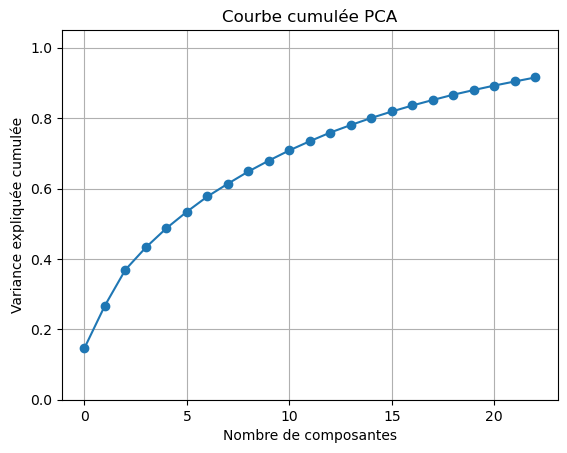

In [808]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance, marker='o')
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Courbe cumulée PCA")
plt.ylim(0, 1.05)
plt.grid()
plt.show()

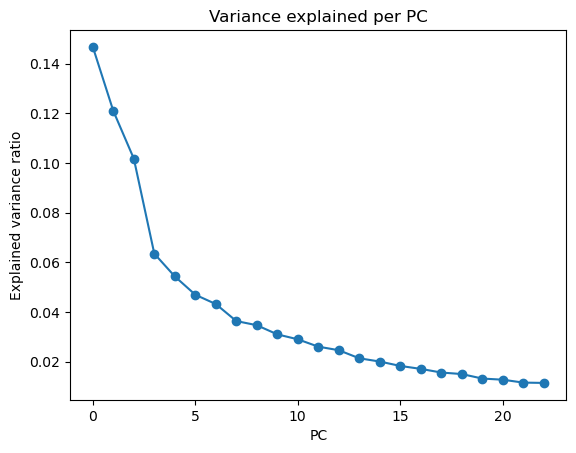

In [809]:
explained_variance = pca.explained_variance_ratio_
plt.plot(explained_variance, marker="o")
plt.xlabel("PC")
plt.ylabel("Explained variance ratio")
plt.title("Variance explained per PC")
plt.show()

### Dendrogramme


#### Initialisation

In [810]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


import seaborn as sns


from matplotlib.colors import ListedColormap, TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

In [811]:
def sample_count_niche(nodes_by_sample):
     #créer comme une matrice avec en index patient-sample et en colonne les clusters/niches. 
    # les valeurs de la matrice = nombre de cell dans chaque niche selon loc
    #nodes_by_sample = dict avec différents dataframes pour chaque sample et contenant chacuns les nodes
    keys = list(nodes_by_sample.keys())
    df_total = []

    for key in keys:
        df = nodes_by_sample[key]
        
        df_count = df["Niche"].value_counts().to_dict()
        df_count["id"] = key
        
        df_total.append(df_count)

    return  pd.DataFrame(df_total).set_index("id").fillna(0)



In [812]:
#data frame avec location by patient-sample que j'utilise dans les plots
df_patient_loc = nodes_cluster_labeled_and_metadata.groupby("id", as_index=False)["location"].first()

#dictionnaire avec chaque key = une image = patient-sample et dedans il y a les nodes
nodes_by_sample = dict(tuple(nodes_cluster_labeled_and_metadata.groupby("id")))
#création Matrice id(patient-sample) / niche avec nombre de cell dans niche par id

df_total_count_sample = sample_count_niche(nodes_by_sample)
#je met les colonnes dans ordre croissant (niches nommées avec des nombres)
df_total_count_sample = df_total_count_sample.reindex(sorted(df_total_count_sample.columns.astype(int)), axis=1)

#### Plot 

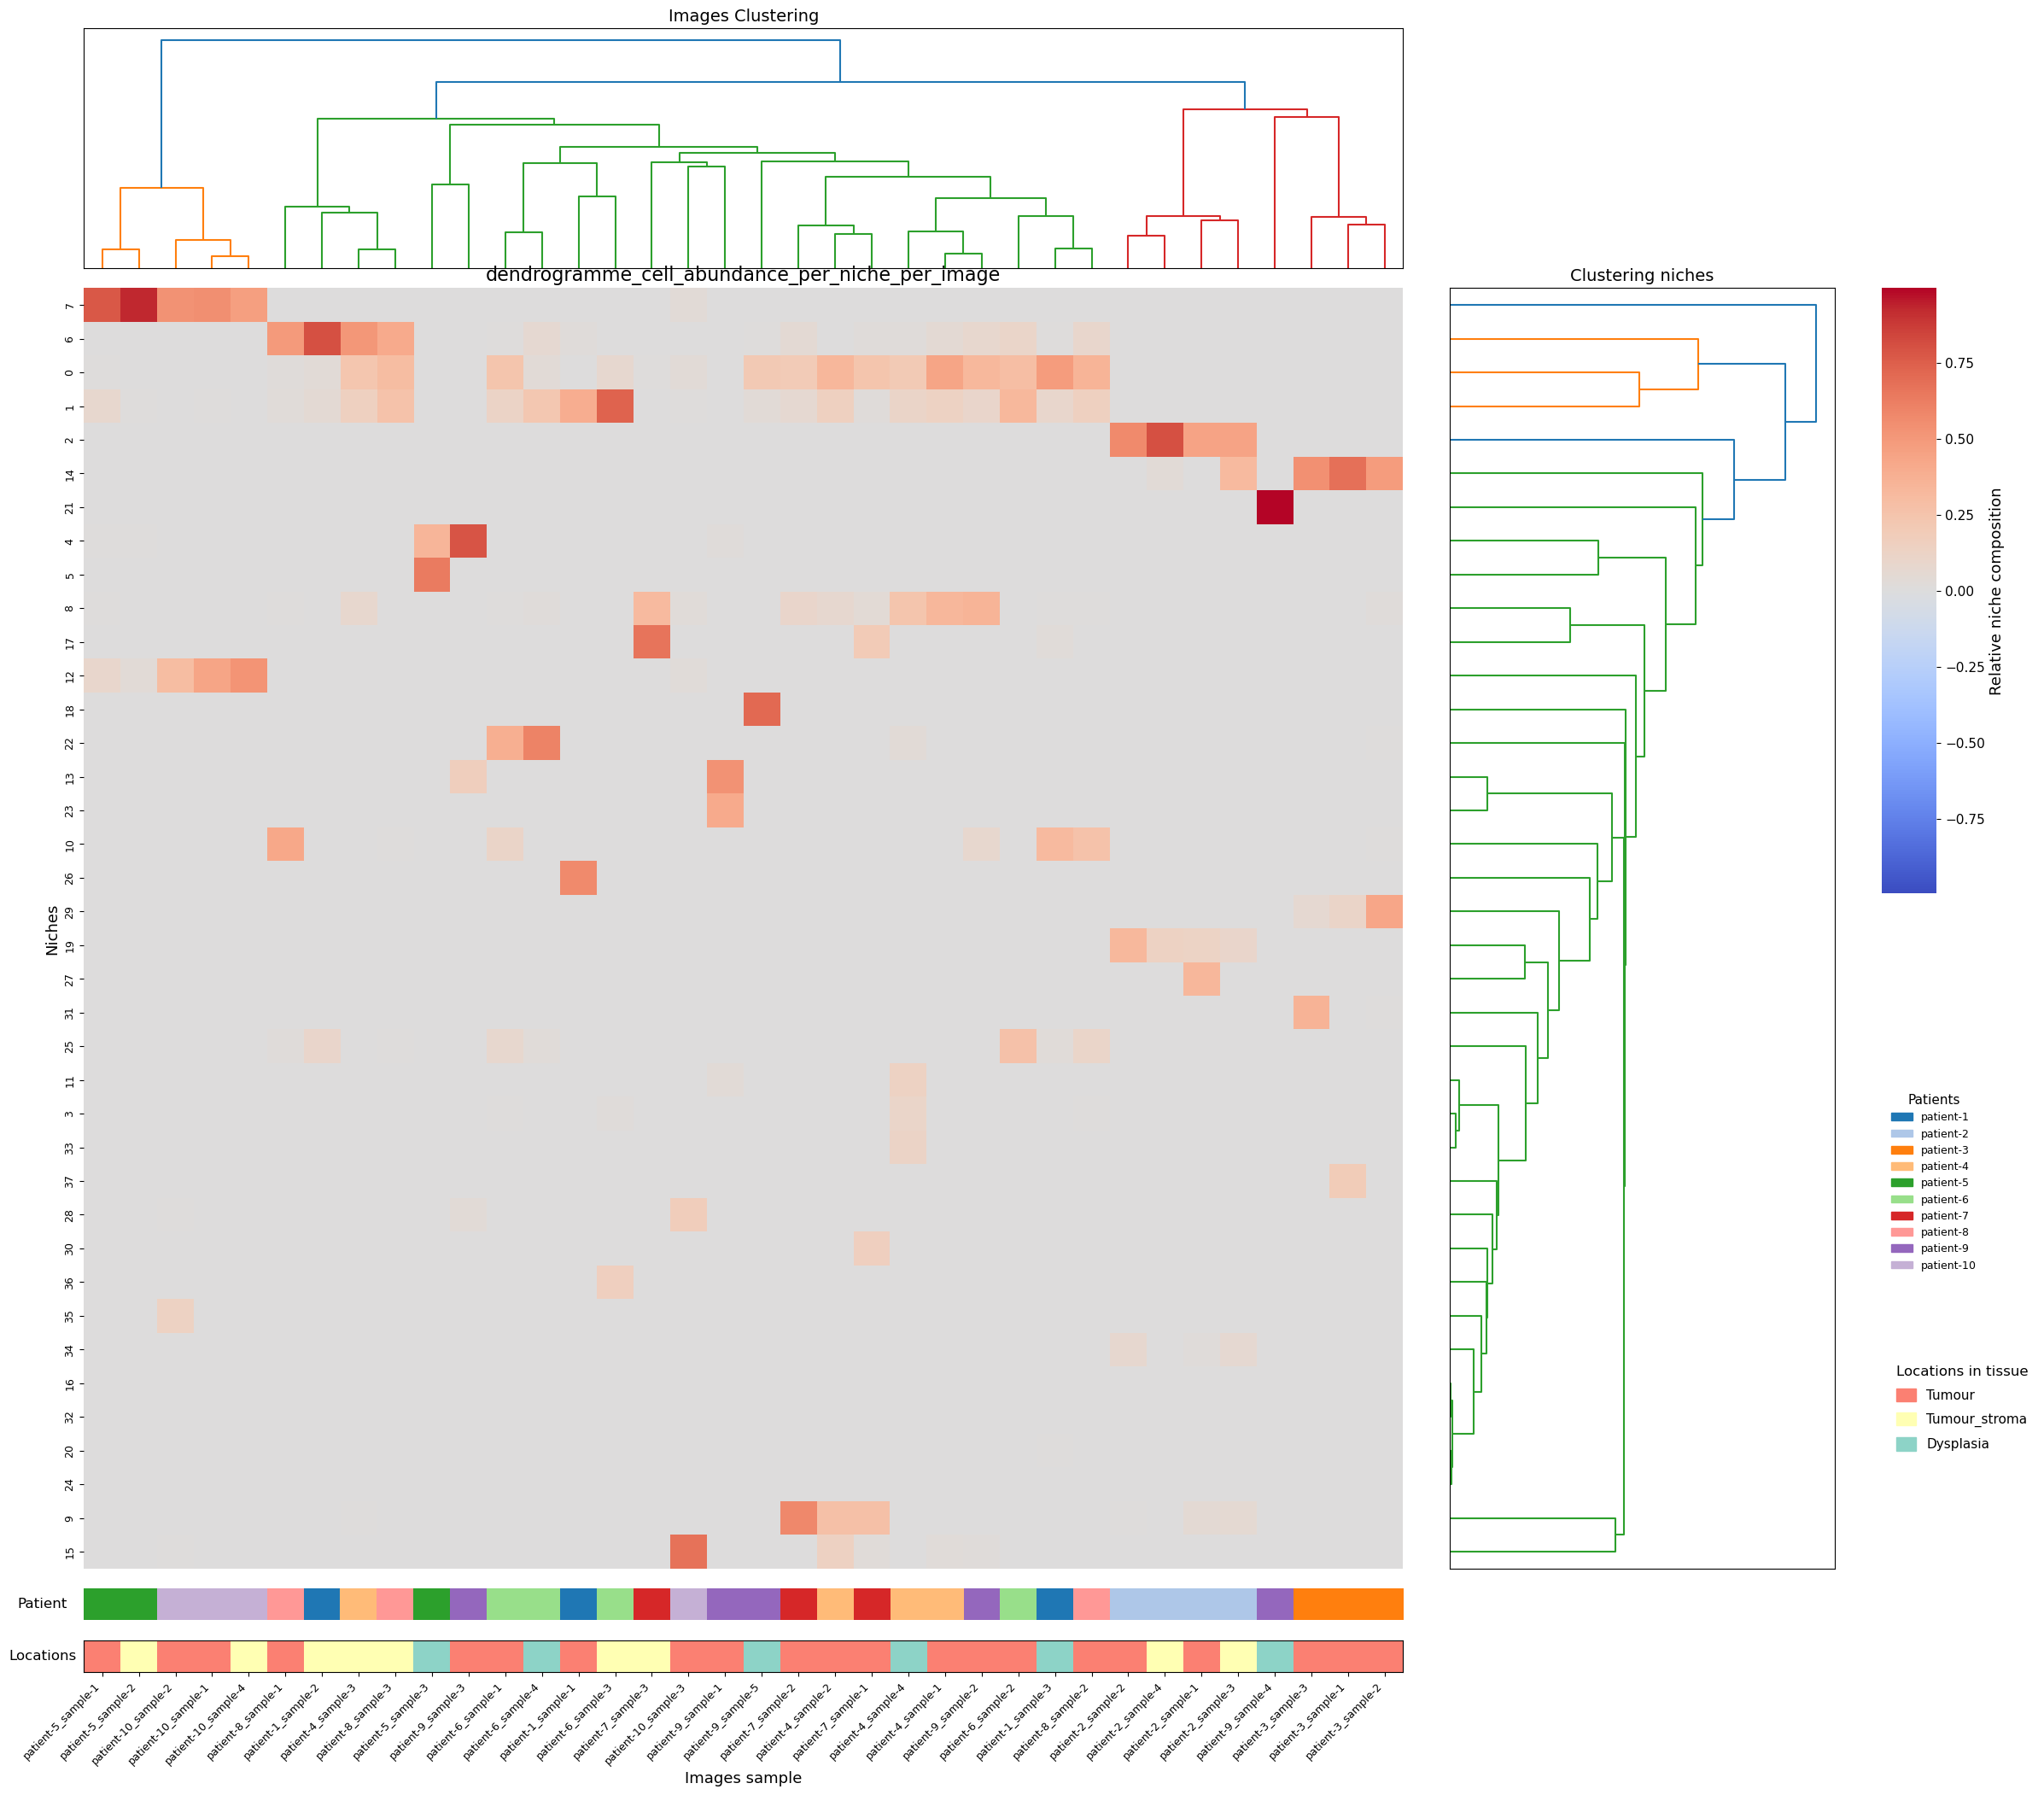

In [813]:
#"dendro_heatmap_cell_abundance_per_niche


#ajouter couleur par patient au dessus loc, mettre couleur, mettre un bloc couleur en haut heat map et autre en bas




#save_dir = Path("./OUTPUT/assortativity")

# ------------------------------------------------------------------
# 1. Préparation des données
# ------------------------------------------------------------------

data = df_total_count_sample
#je rajoute colonne id(patient-sample), patient et sample

if without_normal:
    data["location"] = df_patient_loc.set_index("id")["location"].reindex(data.index)
    data = data[data['location'] != 'Adjacent_normal']
    heatmap_data = data.copy()
    heatmap_data = heatmap_data.drop(columns=["location"])
    locations = data["location"].astype(str)

else :
    data["location"] = df_patient_loc.set_index("id")["location"].reindex(data.index)
    heatmap_data = data.drop(columns=["location"])
    locations = data["location"].astype(str)


if normalize:
    #normalisation par ligne/patient
    heatmap_data = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

heatmap_data = heatmap_data.T.astype(float)



heatmap_data = heatmap_data.replace([np.inf, -np.inf], np.nan)
heatmap_data = heatmap_data.dropna(axis=0, how="all")
heatmap_data = heatmap_data.dropna(axis=1, how="all")

# ------------------------------------------------------------------
# 2. Clustering des colonnes et des lignes
# ------------------------------------------------------------------

cluster_matrix_cols = heatmap_data.T.fillna(0)
col_linkage = linkage(pdist(cluster_matrix_cols, metric="euclidean"), method="ward")

cluster_matrix_rows = heatmap_data.fillna(0)
row_linkage = linkage(pdist(cluster_matrix_rows, metric="euclidean"), method="ward")

# ------------------------------------------------------------------
# 3. Ordre des feuilles
# ------------------------------------------------------------------

col_dendro_preview = dendrogram(col_linkage, no_plot=True)
col_leaf_order = col_dendro_preview["leaves"]

row_dendro_preview = dendrogram(row_linkage, no_plot=True)
row_leaf_order = row_dendro_preview["leaves"]

heatmap_data = heatmap_data.iloc[row_leaf_order, col_leaf_order]

# ------------------------------------------------------------------
# 4. Bande de couleur pour la location
# ------------------------------------------------------------------

location_series = data.loc[heatmap_data.columns, "location"]


unique_locations = location_series.dropna().unique()
if location_to_color == None:
    palette = sns.color_palette("Set3", n_colors=len(unique_locations))
    location_to_color = dict(zip(unique_locations, palette))

location_to_int = {loc: i for i, loc in enumerate(unique_locations)}
location_ints = np.array([location_to_int.get(loc, -1) for loc in location_series])

annotation_colors = [
    location_to_color[loc]
    for loc in unique_locations
]
if (location_ints == -1).any():
    annotation_colors.append((0.0, 0.0, 0.0))
    missing_index = len(annotation_colors) - 1
    location_ints = np.where(location_ints == -1, missing_index, location_ints)

location_cmap = ListedColormap(annotation_colors)

# ------------------------------------------------------------------
# Annotation patient
# ------------------------------------------------------------------

patient_series = pd.Series(
    heatmap_data.columns.str.split("_").str[0],
    index=heatmap_data.columns
)

unique_patients = sorted(
    patient_series.unique(),
    key=lambda x: int(x.split("-")[-1])
)

patient_palette = sns.color_palette(
    "tab20",
    n_colors=len(unique_patients)
)

patient_to_color = dict(
    zip(unique_patients, patient_palette)
)

patient_to_int = {
    pat: i
    for i, pat in enumerate(unique_patients)
}

patient_ints = np.array(
    [patient_to_int[p] for p in patient_series]
)

patient_cmap = ListedColormap(
    [patient_to_color[p] for p in unique_patients]
)

# ------------------------------------------------------------------
# 5. Normalisation de la heatmap
# ------------------------------------------------------------------

vals = heatmap_data.to_numpy()
valid_vals = vals[~np.isnan(vals)]

if valid_vals.size == 0:
    raise ValueError("La matrice ne contient aucune valeur exploitable.")

zlim = np.nanmax(np.abs(valid_vals))
norm = TwoSlopeNorm(vmin=-zlim, vcenter=0, vmax=zlim)

cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color="black")

# ------------------------------------------------------------------
# 6. Mise en page
# ------------------------------------------------------------------

fig = plt.figure(figsize=(28, 25))

gs = GridSpec(
    nrows=4,
    ncols=3,
    width_ratios=[24, 7, 1],
    height_ratios=[3, 16, 0.4, 0.4],
    wspace=0.08,
    hspace=0.05
)

ax_dendro_col = fig.add_subplot(gs[0, 0])
ax_heat = fig.add_subplot(gs[1, 0])

ax_patient = fig.add_subplot(
    gs[2, 0],
    sharex=ax_heat
)

ax_loc = fig.add_subplot(
    gs[3, 0],
    sharex=ax_heat
)

ax_dendro_row = fig.add_subplot(gs[1, 1])

right_gs = gs[1, 2].subgridspec(
    nrows=2,
    ncols=1,
    height_ratios=[5, 4],
    hspace=0.35
)

cbar_ax = fig.add_subplot(right_gs[0, 0])
legend_ax = fig.add_subplot(right_gs[1, 0])

ax_top_unused_1 = fig.add_subplot(gs[0, 1])
ax_top_unused_2 = fig.add_subplot(gs[0, 2])
ax_bottom_unused_1 = fig.add_subplot(gs[3, 1])
ax_bottom_unused_2 = fig.add_subplot(gs[3, 2])

ax_top_unused_1.axis("off")
ax_top_unused_2.axis("off")
ax_bottom_unused_1.axis("off")
ax_bottom_unused_2.axis("off")

# ------------------------------------------------------------------
# 7. Dendrogramme des colonnes
# ------------------------------------------------------------------

dendrogram(
    col_linkage,
    ax=ax_dendro_col,
    no_labels=True,
    color_threshold=None
)

ax_dendro_col.set_xticks([])
ax_dendro_col.set_yticks([])
ax_dendro_col.set_xlabel("")
ax_dendro_col.set_ylabel("")
ax_dendro_col.set_title("Images Clustering", fontsize=14)

# ------------------------------------------------------------------
# 8. Heatmap principale
# ------------------------------------------------------------------

sns.heatmap(
    heatmap_data,
    cmap=cmap,
    center=None,
    vmin=-zlim,
    vmax=zlim,
    ax=ax_heat,
    cbar_ax=cbar_ax,
    cbar_kws={"label": "Niches"},
    yticklabels=heatmap_data.index,
    xticklabels=False
)

ax_heat.set_ylabel("Niches", fontsize=13)
ax_heat.set_xlabel("")
ax_heat.set_title("dendrogramme_cell_abundance_per_niche_per_image", fontsize=16)
ax_heat.tick_params(axis="x", bottom=False, labelbottom=False)
ax_heat.tick_params(axis="y", labelsize=9)

# On garde les labels de lignes à gauche de la heatmap."dendro_heatmap_cell_abundance_per_niche_without_adjacent_normal
ax_heat.yaxis.tick_left()
ax_heat.yaxis.set_label_position("left")

# ------------------------------------------------------------------
# 9. Dendrogramme des lignes
# ------------------------------------------------------------------

dendrogram(
    row_linkage,
    ax=ax_dendro_row,
    orientation="right",
    no_labels=True,
    color_threshold=None
)

ax_dendro_row.set_xticks([])
ax_dendro_row.set_yticks([])
ax_dendro_row.set_xlabel("")
ax_dendro_row.set_ylabel("")
ax_dendro_row.set_title("Clustering niches", fontsize=14)

n_rows = heatmap_data.shape[0]
ax_dendro_row.set_ylim(10 * n_rows, 0)

# ------------------------------------------------------------------
# 10. Bande patient
# ------------------------------------------------------------------

ax_patient.imshow(
    patient_ints[np.newaxis, :],
    aspect="auto",
    cmap=patient_cmap,
    interpolation="nearest",
    extent=[0, len(patient_ints), 0, 1]
)

# Titre de la bande
ax_patient.set_ylabel(
    "Patient",
    rotation=0,
    labelpad=35,
    va="center",
    fontsize=12
)

# Supprime tout axe visible
ax_patient.set_yticks([])
ax_patient.set_xticks([])
ax_patient.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Optionnel : enlever les bordures
for spine in ax_patient.spines.values():
    spine.set_visible(False)


# ------------------------------------------------------------------
# 10. Bande de location
# ------------------------------------------------------------------

ax_loc.imshow(
    location_ints[np.newaxis, :],
    aspect="auto",
    cmap=location_cmap,
    interpolation="nearest",
    extent=[0, len(location_ints), 0, 1]
)

ax_loc.set_yticks([])
ax_loc.set_ylabel("Locations", rotation=0, labelpad=35, va="center", fontsize=12)

x_centers = np.arange(len(heatmap_data.columns)) + 0.5
ax_loc.set_xticks(x_centers)
ax_loc.set_xticklabels(heatmap_data.columns, rotation=45, ha="right", fontsize=9)
ax_loc.set_xlim(0, len(location_ints))
ax_loc.set_xlabel("Images sample", fontsize=13)

# ------------------------------------------------------------------
# 11. Colorbar et légende
# ------------------------------------------------------------------

cbar_ax.tick_params(labelsize=11)
cbar_ax.set_ylabel("Relative niche composition", fontsize=13)

legend_ax.axis("off")

# --------------------------
# Patient legend
# --------------------------

patient_handles = [
    mpatches.Patch(
        color=patient_to_color[p],
        label=p
    )
    for p in unique_patients
]

legend_patient = legend_ax.legend(
    handles=patient_handles,
    title="Patients",
    loc="upper left",
    bbox_to_anchor=(0, 1),
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)

legend_ax.add_artist(legend_patient)

# --------------------------
# Location legend
# --------------------------

location_handles = [
    mpatches.Patch(
        color=location_to_color[loc],
        label=loc
    )
    for loc in unique_locations
]

legend_ax.legend(
    handles=location_handles,
    title="Locations in tissue",
    loc="upper left",
    bbox_to_anchor=(0, 0.45),
    frameon=False,
    fontsize=11,
    title_fontsize=12,
    handlelength=1.5,
    handleheight=1.2,
    labelspacing=0.8,
    borderpad=0.6
)
if save :
    if without_normal == True:
        plt.savefig(plot_dir / "dendro_cell_abundance_per_niche_per_image_without_adjacent_normal.png", bbox_inches="tight")
    else :
        plt.savefig(plot_dir / "dendro_cell_abundance_per_niche_per_image.png", bbox_inches="tight")
plt.show()

## Par patient

In [814]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

from matplotlib.colors import ListedColormap, TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

In [815]:
def sample_count_niche(nodes_by_sample):
     #créer comme une matrice avec en index patient-sample et en colonne les clusters/niches. 
    # les valeurs de la matrice = nombre de cell dans chaque niche selon loc
    #nodes_by_sample = dict avec différents dataframes pour chaque sample et contenant chacuns les nodes
    keys = list(nodes_by_sample.keys())
    df_total = []

    for key in keys:
        df = nodes_by_sample[key]
        
        df_count = df["Niche"].value_counts().to_dict()
        df_count["id"] = key
        
        df_total.append(df_count)

    return  pd.DataFrame(df_total).set_index("id").fillna(0)



In [816]:
#data frame avec location by patient-sample que j'utilise dans les plots
df_patient_loc = nodes_cluster_labeled_and_metadata.groupby("id", as_index=False)["location"].first()

#dictionnaire avec chaque key = une image = patient-sample et dedans il y a les nodes
nodes_by_sample = dict(tuple(nodes_cluster_labeled_and_metadata.groupby("id")))
#création Matrice id(patient-sample) / niche avec nombre de cell dans niche par id

df_total_count_sample = sample_count_niche(nodes_by_sample)
#je met les colonnes dans ordre croissant (niches nommées avec des nombres)
df_total_count_sample = df_total_count_sample.reindex(sorted(df_total_count_sample.columns.astype(int)), axis=1)

#### Plot dendrogramme

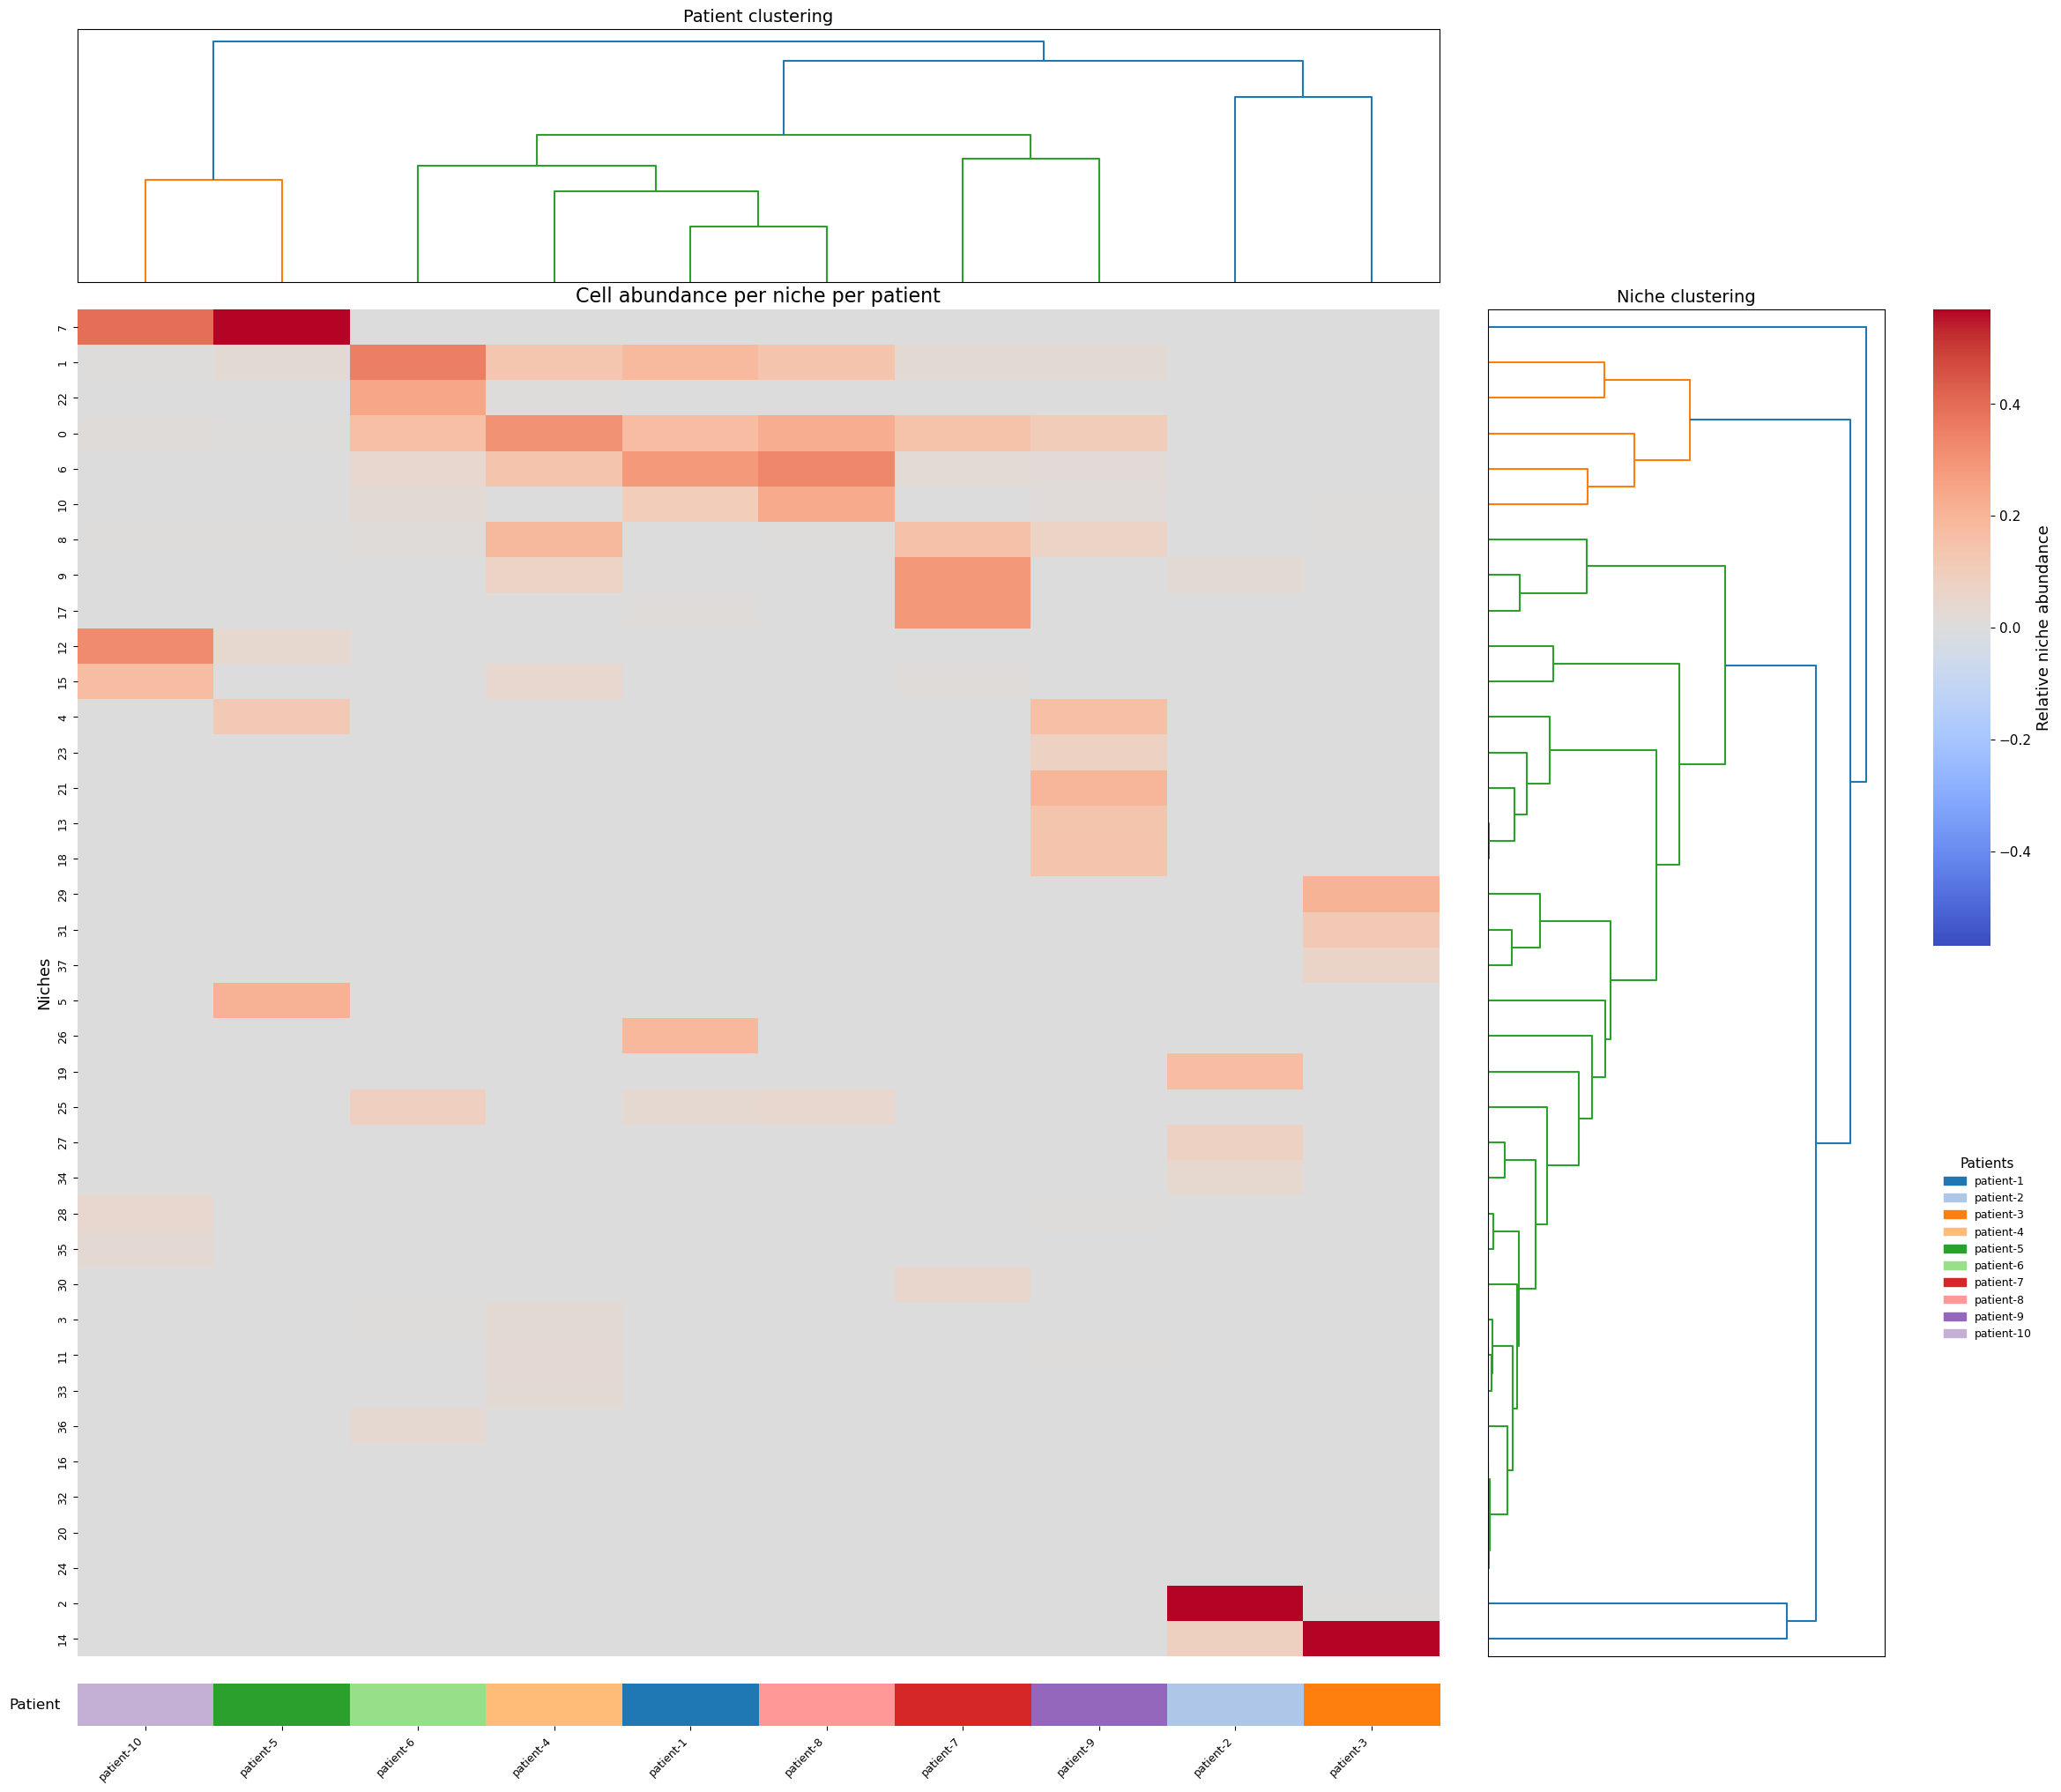

In [817]:
# ------------------------------------------------------------------
# 1. Préparation des données
# ------------------------------------------------------------------
df_total_count_sample = sample_count_niche(nodes_by_sample)
#je met les colonnes dans ordre croissant (niches nommées avec des nombres)
df_total_count_sample = df_total_count_sample.reindex(sorted(df_total_count_sample.columns.astype(int)), axis=1)

if without_normal:
    df["location"] = df_patient_loc.set_index("id")["location"].reindex(df.index)
    df = df[df["location"] != "Adjacent_normal"]

df["patient"] = df.index.str.split("_").str[0]
df = df.drop(columns=["location"], errors="ignore")

# Somme par patient
df_patient = df.groupby("patient").sum(numeric_only=True)

heatmap_data = df_patient.copy()

# Normalisation par patient
if normalize:
    heatmap_data = heatmap_data.div(
        heatmap_data.sum(axis=1),
        axis=0
    )

# Niches en lignes, patients en colonnes
heatmap_data = heatmap_data.T.astype(float)

# Nettoyage
heatmap_data = heatmap_data.replace([np.inf, -np.inf], np.nan)
heatmap_data = heatmap_data.dropna(axis=0, how="all")
heatmap_data = heatmap_data.dropna(axis=1, how="all")

# ------------------------------------------------------------------
# 2. Clustering
# ------------------------------------------------------------------

col_linkage = linkage(
    pdist(heatmap_data.T.fillna(0), metric="euclidean"),
    method="ward"
)

row_linkage = linkage(
    pdist(heatmap_data.fillna(0), metric="euclidean"),
    method="ward"
)

# ------------------------------------------------------------------
# 3. Ordre des feuilles
# ------------------------------------------------------------------

col_order = dendrogram(col_linkage, no_plot=True)["leaves"]
row_order = dendrogram(row_linkage, no_plot=True)["leaves"]

heatmap_data = heatmap_data.iloc[row_order, col_order]

# ------------------------------------------------------------------
# Couleurs patients
# ------------------------------------------------------------------

patient_series = pd.Series(
    heatmap_data.columns,
    index=heatmap_data.columns
)

unique_patients = sorted(
    patient_series.unique(),
    key=lambda x: int(x.split("-")[-1])
)

patient_palette = sns.color_palette(
    "tab20",
    n_colors=len(unique_patients)
)

patient_to_color = dict(
    zip(unique_patients, patient_palette)
)

patient_to_int = {
    pat: i
    for i, pat in enumerate(unique_patients)
}

patient_ints = np.array(
    [patient_to_int[p] for p in patient_series]
)

patient_cmap = ListedColormap(
    [patient_to_color[p] for p in unique_patients]
)

# ------------------------------------------------------------------
# 4. Couleurs
# ------------------------------------------------------------------

vals = heatmap_data.to_numpy()
valid_vals = vals[~np.isnan(vals)]

if valid_vals.size == 0:
    raise ValueError("La matrice ne contient aucune valeur exploitable.")

zlim = np.nanmax(np.abs(valid_vals))

cmap = plt.cm.coolwarm.copy()
cmap.set_bad("black")

# ------------------------------------------------------------------
# 5. Layout
# ------------------------------------------------------------------

fig = plt.figure(figsize=(28, 25))

gs = GridSpec(
    nrows=3,
    ncols=3,
    width_ratios=[24, 7, 1],
    height_ratios=[3, 16, 0.5],
    wspace=0.08,
    hspace=0.05
)

ax_dendro_col = fig.add_subplot(gs[0, 0])
ax_heat = fig.add_subplot(gs[1, 0])
ax_dendro_row = fig.add_subplot(gs[1, 1])

ax_patient = fig.add_subplot(
    gs[2, 0],
    sharex=ax_heat
)

right_gs = gs[1, 2].subgridspec(
    nrows=2,
    ncols=1,
    height_ratios=[5, 4],
    hspace=0.35
)

cbar_ax = fig.add_subplot(right_gs[0, 0])
legend_ax = fig.add_subplot(right_gs[1, 0])

fig.add_subplot(gs[0, 1]).axis("off")
fig.add_subplot(gs[0, 2]).axis("off")

fig.add_subplot(gs[2, 1]).axis("off")
fig.add_subplot(gs[2, 2]).axis("off")

# ------------------------------------------------------------------
# 6. Dendrogramme colonnes
# ------------------------------------------------------------------

dendrogram(
    col_linkage,
    ax=ax_dendro_col,
    no_labels=True,
    color_threshold=None
)

ax_dendro_col.set_xticks([])
ax_dendro_col.set_yticks([])
ax_dendro_col.set_title(
    "Patient clustering",
    fontsize=14
)

# ------------------------------------------------------------------
# 7. Heatmap
# ------------------------------------------------------------------

# 7. Heatmap
# ------------------------------------------------------------------

sns.heatmap(
    heatmap_data,
    cmap=cmap,
    center=0,
    vmin=-zlim,
    vmax=zlim,
    ax=ax_heat,
    cbar_ax=cbar_ax,
    yticklabels=heatmap_data.index,
    xticklabels=False
)

ax_heat.set_ylabel("Niches", fontsize=13)
ax_heat.set_xlabel("")

ax_heat.set_title(
    "Cell abundance per niche per patient",
    fontsize=16
)

# Affichage des patients sur l'axe X
x_centers = np.arange(len(heatmap_data.columns)) + 0.5

ax_heat.set_xticks(x_centers)
ax_heat.set_xticklabels([])

ax_heat.tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)

ax_heat.tick_params(axis="y", labelsize=9)


ax_heat.yaxis.tick_left()
ax_heat.yaxis.set_label_position("left")

# ------------------------------------------------------------------
# Bande patient
# ------------------------------------------------------------------

ax_patient.imshow(
    patient_ints[np.newaxis, :],
    aspect="auto",
    cmap=patient_cmap,
    interpolation="nearest",
    extent=[0, len(patient_ints), 0, 1]
)

ax_patient.set_ylabel(
    "Patient",
    rotation=0,
    labelpad=35,
    va="center",
    fontsize=12
)

ax_patient.set_yticks([])

x_centers = np.arange(len(heatmap_data.columns)) + 0.5

ax_patient.set_xticks(x_centers)
ax_patient.set_xticklabels(
    heatmap_data.columns,
    rotation=45,
    ha="right",
    fontsize=9
)

for spine in ax_patient.spines.values():
    spine.set_visible(False)

# ------------------------------------------------------------------
# 8. Dendrogramme lignes
# ------------------------------------------------------------------

dendrogram(
    row_linkage,
    ax=ax_dendro_row,
    orientation="right",
    no_labels=True,
    color_threshold=None
)

ax_dendro_row.set_xticks([])
ax_dendro_row.set_yticks([])
ax_dendro_row.set_title(
    "Niche clustering",
    fontsize=14
)

ax_dendro_row.set_ylim(
    10 * heatmap_data.shape[0],
    0
)

# ------------------------------------------------------------------
# 9. Colorbar
# ------------------------------------------------------------------

cbar_ax.tick_params(labelsize=11)
cbar_ax.set_ylabel(
    "Relative niche abundance",
    fontsize=13
)

legend_ax.axis("off")

patient_handles = [
    mpatches.Patch(
        color=patient_to_color[p],
        label=p
    )
    for p in unique_patients
]

legend_ax.legend(
    handles=patient_handles,
    title="Patients",
    loc="upper left",
    frameon=False,
    fontsize=9,
    title_fontsize=11
)

# ------------------------------------------------------------------
# 10. Save
# ------------------------------------------------------------------

if save :
    if without_normal :
        plt.savefig(plot_dir / "dendro_cell_abundance_per_niche_per_patient_without_adjacent_normal.png", bbox_inches="tight")
    if without_normal == False : 
        plt.savefig(plot_dir / "dendro_patient_cell_abundance_per_niche_per_patient.png", bbox_inches="tight")

plt.show()

